In [1]:
import pandas as pd
import polars as pl
from pathlib import Path

In [2]:
pattern = "IR" 
parent = Path(f"../datasets/{pattern}_datasets/normal").resolve()
assert parent.is_dir()

motif_df = pl.read_csv(
    parent / f"{pattern}_biophysical.tsv.gz",
    separator="\t",
    has_header=True
)
motif_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,species_taxid,organism_name,group,genome_size,gc_percent,domain,phylum,family,kingdom,STR_coverage_sequence,STR_coverage_arm
str,i64,i64,str,i64,str,i64,str,i64,str,i64,str,str,i64,f64,str,str,str,str,i64,i64
"""NC_003551.1""",53509,53539,"""gatgacgtcga""",11,"""gaaggtca""",8,"""gatgacgtcgagaaggtcatcgacgtcatc""",30,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0
"""NC_003551.1""",55509,55537,"""tcgtcgggacgac""",13,"""ac""",2,"""tcgtcgggacgacacgtcgtcccgacga""",28,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0
"""NC_003551.1""",66661,66683,"""gagcacgctcc""",11,""".""",0,"""gagcacgctccggagcgtgctc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0
"""NC_003551.1""",99585,99607,"""gggggctcga""",10,"""tg""",2,"""gggggctcgatgtcgagccccc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0
"""NC_003551.1""",168786,168808,"""gcggaacgtc""",10,"""ca""",2,"""gcggaacgtccagacgttccgc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""OZ001188.1""",2687933,2687961,"""tgcggatgtgg""",11,"""tcacgc""",6,"""tgcggatgtggtcacgcccacatccgca""",28,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0
"""OZ001188.1""",2715434,2715463,"""ctcaagctgtt""",11,"""gtgtttg""",7,"""ctcaagctgttgtgtttgaacagcttgag""",29,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0
"""OZ001188.1""",2716227,2716254,"""ccgccgctgcg""",11,"""ttcgt""",5,"""ccgccgctgcgttcgtcgcagcggcgg""",27,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0


In [8]:
from Bio.Seq import Seq 

motif_df = motif_df.with_columns(
    right_arm=pl.col("sequence_of_arm").map_elements(lambda x: str(Seq(x).reverse_complement()), return_dtype=str)
)
motif_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,species_taxid,organism_name,group,genome_size,gc_percent,domain,phylum,family,kingdom,STR_coverage_sequence,STR_coverage_arm,right_arm,arm_A_count,arm_a_count,arm_g_count,arm_c_count,arm_t_count,right_arm_a_count,right_arm_g_count,right_arm_c_count,right_arm_t_count
str,i64,i64,str,i64,str,i64,str,i64,str,i64,str,str,i64,f64,str,str,str,str,i64,i64,str,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""NC_003551.1""",53509,53539,"""gatgacgtcga""",11,"""gaaggtca""",8,"""gatgacgtcgagaaggtcatcgacgtcatc""",30,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""tcgacgtcatc""",3,3,4,2,2,2,2,4,3
"""NC_003551.1""",55509,55537,"""tcgtcgggacgac""",13,"""ac""",2,"""tcgtcgggacgacacgtcgtcccgacga""",28,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""gtcgtcccgacga""",2,2,5,4,2,2,4,5,2
"""NC_003551.1""",66661,66683,"""gagcacgctcc""",11,""".""",0,"""gagcacgctccggagcgtgctc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""ggagcgtgctc""",2,2,3,5,1,1,5,3,2
"""NC_003551.1""",99585,99607,"""gggggctcga""",10,"""tg""",2,"""gggggctcgatgtcgagccccc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""tcgagccccc""",1,1,6,2,1,1,2,6,1
"""NC_003551.1""",168786,168808,"""gcggaacgtc""",10,"""ca""",2,"""gcggaacgtccagacgttccgc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""gacgttccgc""",2,2,4,3,1,1,3,4,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""OZ001188.1""",2687933,2687961,"""tgcggatgtgg""",11,"""tcacgc""",6,"""tgcggatgtggtcacgcccacatccgca""",28,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""ccacatccgca""",1,1,6,1,3,3,1,6,1
"""OZ001188.1""",2715434,2715463,"""ctcaagctgtt""",11,"""gtgtttg""",7,"""ctcaagctgttgtgtttgaacagcttgag""",29,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""aacagcttgag""",2,2,2,3,4,4,3,2,2
"""OZ001188.1""",2716227,2716254,"""ccgccgctgcg""",11,"""ttcgt""",5,"""ccgccgctgcgttcgtcgcagcggcgg""",27,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""cgcagcggcgg""",0,0,4,6,1,1,6,4,0


In [52]:
motif_df = motif_df.with_columns(
    *[pl.col("sequence_of_arm").str.count_matches(n).alias(f"arm_{n}_count") for n in "agct"],
    *[pl.col("right_arm").str.count_matches(n).alias(f"right_arm_{n}_count") for n in "agct"]
)
motif_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,species_taxid,organism_name,group,genome_size,gc_percent,domain,phylum,family,kingdom,STR_coverage_sequence,STR_coverage_arm,right_arm,arm_A_count,arm_a_count,arm_g_count,arm_c_count,arm_t_count,right_arm_a_count,right_arm_g_count,right_arm_c_count,right_arm_t_count
str,i64,i64,str,i64,str,i64,str,i64,str,i64,str,str,i64,f64,str,str,str,str,i64,i64,str,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""NC_003551.1""",53509,53539,"""gatgacgtcga""",11,"""gaaggtca""",8,"""gatgacgtcgagaaggtcatcgacgtcatc""",30,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""tcgacgtcatc""",3,3,4,2,2,2,2,4,3
"""NC_003551.1""",55509,55537,"""tcgtcgggacgac""",13,"""ac""",2,"""tcgtcgggacgacacgtcgtcccgacga""",28,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""gtcgtcccgacga""",2,2,5,4,2,2,4,5,2
"""NC_003551.1""",66661,66683,"""gagcacgctcc""",11,""".""",0,"""gagcacgctccggagcgtgctc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""ggagcgtgctc""",2,2,3,5,1,1,5,3,2
"""NC_003551.1""",99585,99607,"""gggggctcga""",10,"""tg""",2,"""gggggctcgatgtcgagccccc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""tcgagccccc""",1,1,6,2,1,1,2,6,1
"""NC_003551.1""",168786,168808,"""gcggaacgtc""",10,"""ca""",2,"""gcggaacgtccagacgttccgc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""gacgttccgc""",2,2,4,3,1,1,3,4,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""OZ001188.1""",2687933,2687961,"""tgcggatgtgg""",11,"""tcacgc""",6,"""tgcggatgtggtcacgcccacatccgca""",28,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""ccacatccgca""",1,1,6,1,3,3,1,6,1
"""OZ001188.1""",2715434,2715463,"""ctcaagctgtt""",11,"""gtgtttg""",7,"""ctcaagctgttgtgtttgaacagcttgag""",29,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""aacagcttgag""",2,2,2,3,4,4,3,2,2
"""OZ001188.1""",2716227,2716254,"""ccgccgctgcg""",11,"""ttcgt""",5,"""ccgccgctgcgttcgtcgcagcggcgg""",27,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""cgcagcggcgg""",0,0,4,6,1,1,6,4,0


In [80]:
nucleotides = {"a", "g", "c", "t"} 
motif_df = (
      motif_df
        .with_columns(
            sequence=pl.col("sequence").str.to_lowercase(),
            sequence_of_arm=pl.col("sequence_of_arm").str.to_lowercase()
        )
        .filter(
          pl.col("sequence")
            .map_elements(lambda seq: all(n in nucleotides for n in seq),
                          return_dtype=pl.Boolean)
            )
       .with_columns(
            GC_content=(
                  pl.col("sequence_of_arm").str.count_matches("[gc]", literal=False)
            )
       )
       .with_columns(
           GC_content_perc=pl.col("GC_content") / pl.col("arm_length") * 1e2
       )
)
motif_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,species_taxid,organism_name,group,genome_size,gc_percent,domain,phylum,family,kingdom,STR_coverage_sequence,STR_coverage_arm,right_arm,arm_A_count,arm_a_count,arm_g_count,arm_c_count,arm_t_count,right_arm_a_count,right_arm_g_count,right_arm_c_count,right_arm_t_count,GC_content,GC_content_perc
str,i64,i64,str,i64,str,i64,str,i64,str,i64,str,str,i64,f64,str,str,str,str,i64,i64,str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,f64
"""NC_003551.1""",53509,53539,"""gatgacgtcga""",11,"""gaaggtca""",8,"""gatgacgtcgagaaggtcatcgacgtcatc""",30,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""tcgacgtcatc""",3,3,4,2,2,2,2,4,3,6,54.545455
"""NC_003551.1""",55509,55537,"""tcgtcgggacgac""",13,"""ac""",2,"""tcgtcgggacgacacgtcgtcccgacga""",28,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""gtcgtcccgacga""",2,2,5,4,2,2,4,5,2,9,69.230769
"""NC_003551.1""",66661,66683,"""gagcacgctcc""",11,""".""",0,"""gagcacgctccggagcgtgctc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""ggagcgtgctc""",2,2,3,5,1,1,5,3,2,8,72.727273
"""NC_003551.1""",99585,99607,"""gggggctcga""",10,"""tg""",2,"""gggggctcgatgtcgagccccc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""tcgagccccc""",1,1,6,2,1,1,2,6,1,8,80.0
"""NC_003551.1""",168786,168808,"""gcggaacgtc""",10,"""ca""",2,"""gcggaacgtccagacgttccgc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,"""gacgttccgc""",2,2,4,3,1,1,3,4,2,7,70.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""OZ001188.1""",2687933,2687961,"""tgcggatgtgg""",11,"""tcacgc""",6,"""tgcggatgtggtcacgcccacatccgca""",28,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""ccacatccgca""",1,1,6,1,3,3,1,6,1,7,63.636364
"""OZ001188.1""",2715434,2715463,"""ctcaagctgtt""",11,"""gtgtttg""",7,"""ctcaagctgttgtgtttgaacagcttgag""",29,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""aacagcttgag""",2,2,2,3,4,4,3,2,2,5,45.454545
"""OZ001188.1""",2716227,2716254,"""ccgccgctgcg""",11,"""ttcgt""",5,"""ccgccgctgcgttcgtcgcagcggcgg""",27,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,"""cgcagcggcgg""",0,0,4,6,1,1,6,4,0,10,90.909091


In [81]:
grouped_right_left_profile_df = (
    motif_df.group_by("#assembly_accession").agg(
            *[pl.col(f"arm_{n}_count").sum().alias(f"total_arm_{n}_count") for n in "agct"],
            *[pl.col(f"right_arm_{n}_count").sum().alias(f"total_right_arm_{n}_count") for n in "agct"],
            pl.col("arm_length").sum().alias("total_bp_arm"),
            pl.col("species_taxid").first().alias("species_taxid"),
            pl.col("domain").first().alias("domain"),
        )
        .with_columns(
            (pl.col(f"total_arm_{n}_count")/ pl.col("total_bp_arm")).alias(f"total_arm_{n}_fraction") for n in "agct"
        )
        .with_columns(
            (pl.col(f"total_right_arm_{n}_count")/ pl.col("total_bp_arm")).alias(f"total_right_arm_{n}_fraction") for n in "agct"
        )
        .group_by("species_taxid")
        .agg(
            pl.col("domain").first().alias("domain"),
            *[pl.col(f"total_arm_{n}_fraction").mean().alias(f"total_arm_{n}_fraction") for n in "agct"],
            *[pl.col(f"total_right_arm_{n}_fraction").mean().alias(f"total_right_arm_{n}_fraction") for n in "agct"],
        )
)

grouped_right_left_profile_melted_df = []
for n in "agct":
    grouped_right_left_profile_melted_df.append(
                                                        grouped_right_left_profile_df.melt(
                                                                   id_vars=["species_taxid", "domain"], 
                                                                   value_vars=[f"total_arm_{n}_fraction", f"total_right_arm_{n}_fraction"], 
                                                                   variable_name="left_right_arm_group", 
                                                                   value_name="fraction"
                                                    )
                                                    .with_columns(
                                                        nucleotide=pl.lit(n.upper()),
                                                        left_right_arm_group=pl.col("left_right_arm_group").replace(f"total_arm_{n}_fraction", "Left Arm").replace(f"total_right_arm_{n}_fraction", "Right Arm")
                                                    )
    )
grouped_right_left_profile_melted_df = pl.concat(grouped_right_left_profile_melted_df)
grouped_right_left_profile_melted_df

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_87497/3200967473.py:26: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  grouped_right_left_profile_df.melt(


species_taxid,domain,left_right_arm_group,fraction,nucleotide
i64,str,str,f64,str
2839983,"""Bacteria""","""Left Arm""",0.166368,"""A"""
1612311,"""Viruses""","""Left Arm""",0.366667,"""A"""
81947,"""Bacteria""","""Left Arm""",0.459431,"""A"""
669041,"""Bacteria""","""Left Arm""",0.440627,"""A"""
2956255,"""Viruses""","""Left Arm""",0.37037,"""A"""
…,…,…,…,…
2966586,"""Bacteria""","""Right Arm""",0.374672,"""T"""
1334244,"""Viruses""","""Right Arm""",0.322581,"""T"""
2603244,"""Bacteria""","""Right Arm""",0.397664,"""T"""


In [82]:
grouped_right_left_profile_melted_df.filter(pl.col("species_taxid") == 2724899)

species_taxid,domain,left_right_arm_group,fraction,nucleotide
i64,str,str,f64,str
2724899,"""Bacteria""","""Left Arm""",0.367574,"""A"""
2724899,"""Bacteria""","""Right Arm""",0.309406,"""A"""
2724899,"""Bacteria""","""Left Arm""",0.183168,"""G"""
2724899,"""Bacteria""","""Right Arm""",0.139851,"""G"""
2724899,"""Bacteria""","""Left Arm""",0.139851,"""C"""
2724899,"""Bacteria""","""Right Arm""",0.183168,"""C"""
2724899,"""Bacteria""","""Left Arm""",0.309406,"""T"""
2724899,"""Bacteria""","""Right Arm""",0.367574,"""T"""


In [216]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

def common_language_effect_size(x, y):
    n_x = len(x)
    n_y = len(y)
    count = 0
    for xi in x:
        count += np.sum(xi > y)
    return count / (n_x * n_y)

cles_results = []
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
nucleotides = ["A", "C", "G", "T"]
for domain in domains:
    df = grouped_right_left_profile_melted_df.filter(pl.col("domain") == domain).to_pandas()
    
    for nt in nucleotides:
        left_values = df[(df["nucleotide"] == nt) & (df["left_right_arm_group"] == "Left Arm")]["fraction"].values
        right_values = df[(df["nucleotide"] == nt) & (df["left_right_arm_group"] == "Right Arm")]["fraction"].values
        
        if len(left_values) == 0 or len(right_values) == 0:
            cles = np.nan
        else:
            cles = common_language_effect_size(left_values, right_values)
        
        if len(left_values) > 0 and len(right_values) > 0:
            _, pval = mannwhitneyu(left_values, right_values, alternative="two-sided")
        else:
            pval = np.nan
        
        cles_results.append({
            "domain": domain,
            "nucleotide": nt,
            "cles": cles,
            "p_value": pval
        })

cles_df = pd.DataFrame(cles_results)
cles_df


,domain,nucleotide,cles,p_value
0,Archaea,A,0.515001,3.983737e-01
1,Archaea,C,0.491373,6.280887e-01
2,Archaea,G,0.508598,6.280887e-01
3,Archaea,T,0.484974,3.983737e-01
4,Eukaryota,A,0.466968,1.687608e-01
5,Eukaryota,C,0.501962,9.346334e-01
6,Eukaryota,G,0.498014,9.346334e-01
7,Eukaryota,T,0.533020,1.687608e-01
8,Bacteria,A,0.749852,0.000000e+00
9,Bacteria,C,0.560556,3.874864e-55


In [84]:
target = Path("IR_figures/biophysical")
assert target.is_dir()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

G_Left Arm vs. G_Right Arm: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.281e-01 U_stat=1.418e+05
A_Left Arm vs. A_Right Arm: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.984e-01 U_stat=1.436e+05
C_Left Arm vs. C_Right Arm: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.281e-01 U_stat=1.370e+05
T_Left Arm vs. T_Right Arm: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.984e-01 U_stat=1.352e+05
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

G_Left Arm vs. G_Right Arm: Mann-Whitney-Wilcoxon test two-sided with Benjamini-

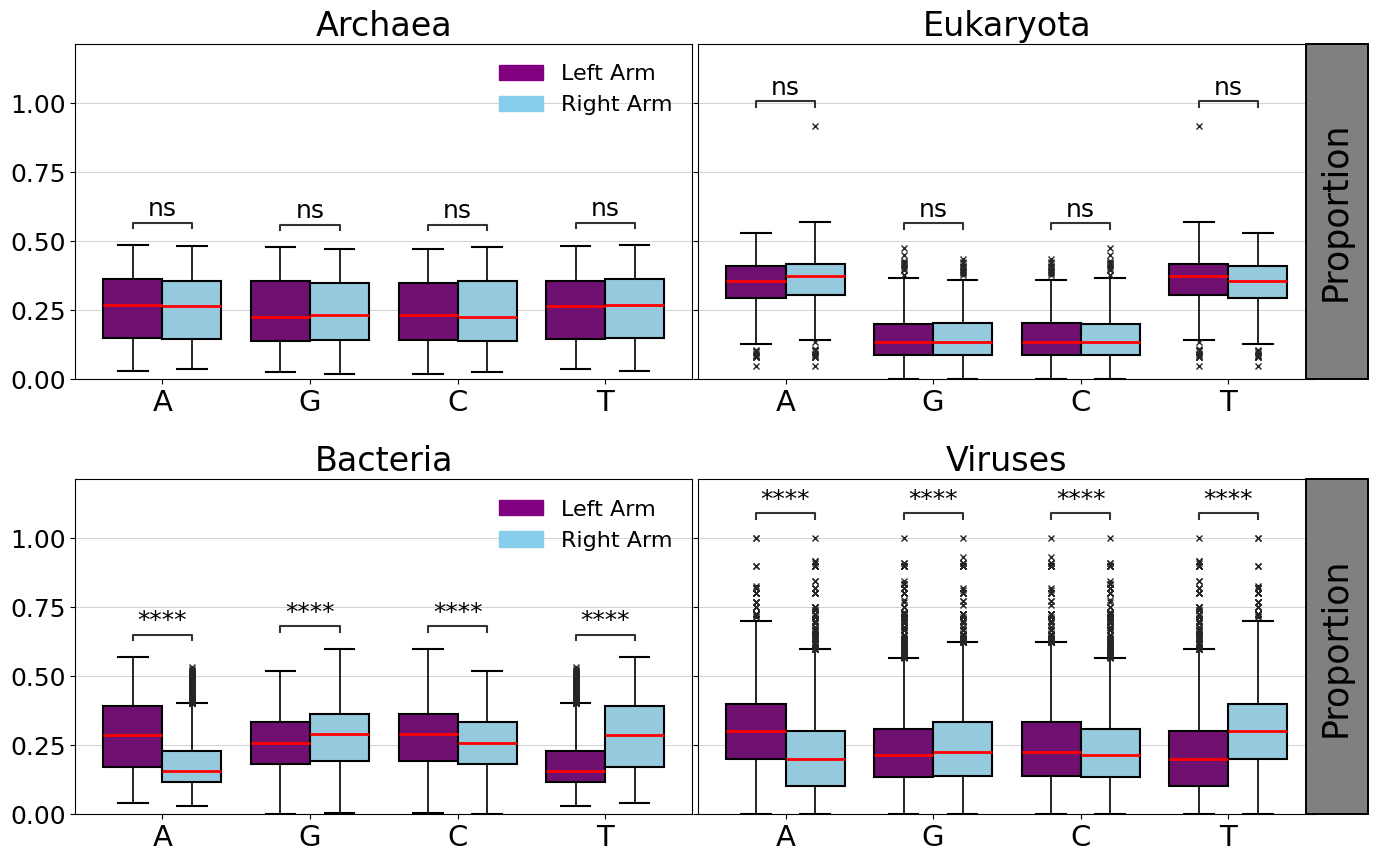

In [215]:
import matplotlib.pyplot as plt 
import seaborn as sns  
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpatches
fig, axes = plt.subplots(nrows=2, ncols=2, sharey=True, sharex=False, figsize=(16, 10))
fig.subplots_adjust(hspace=0.3, wspace=0.01)
axes = axes.flatten()
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"] 

palette = {"Left Arm": "purple", "Right Arm": "skyblue"}
handles = [mpatches.Patch(color=palette[name], label=name) for name in palette]
for i, domain in enumerate(domains):
    ax = axes[i]
    df = grouped_right_left_profile_melted_df.filter(pl.col("domain") == domain)
    sns.boxplot(data=df,
            y="fraction",
            # kind="violin",
            # bw_adjust=4.0,
            boxprops=dict(edgecolor="black", linewidth=1.5),
            whiskerprops=dict(color="black", linewidth=1.2),
            capprops=dict(color="black", linewidth=1.5),
            medianprops=dict(color="red", linewidth=2),
            flierprops=dict(marker="x", markerfacecolor="orange", markersize=5, linestyle="none"),
            hue="left_right_arm_group",
            ax=ax,
            palette=palette,
            legend=False,
            x="nucleotide")
    
    ax.grid(lw=0.4, axis='y')
    ax.set_axisbelow(True)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("", fontsize=20)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=18)
    ax.tick_params(axis="x", labelsize=21)
    if (i == 0 or i == 2):
        ax.legend(handles=handles, prop={"size": 16}, title="", frameon=False)
    ax.set_title(f"{domain}", fontsize=24)
    pairs = [(("A", "Left Arm"), ("A", "Right Arm")),
             (("C", "Left Arm"), ("C", "Right Arm")),
             (("G", "Left Arm"), ("G", "Right Arm")),
             (("T", "Left Arm"), ("T", "Right Arm"))]

    annotator = Annotator(
        ax,
        pairs,
        data=df.to_pandas(),
        x="nucleotide",
        y="fraction",
        hue="left_right_arm_group",
        fontsize=18,
    )
    annotator.configure(test="Mann-Whitney", 
                        text_format="star", 
                        loc="inside", 
                        comparisons_correction="fdr_bh", 
                        verbose=1, 
                        fontsize=18)
    annotator.apply_and_annotate()
    from matplotlib.patches import Rectangle

    if i == 1 or i == 3:
        ax.add_patch(
            Rectangle(
                (0.985, 0.0),  
                0.1,              
                1.0,                 
                transform=ax.transAxes,
                linewidth=1.4,
                facecolor="gray",
                zorder=10,
                clip_on=False,
                edgecolor="black",
                )
        )
        ax.text(
            1.06, 
            0.5,
            "Proportion",
            transform=ax.transAxes,
            rotation=90,
            va="center",
            ha="right",
            fontsize=25,
            color="black",
            zorder=11
        )

fig.savefig(target / "IR_motif_biophysical_properties_left_right_arm_comparison.pdf", transparent=True, bbox_inches="tight")
plt.show()

In [86]:
motif_df.filter(pl.col("species_taxid") == 1352).n_unique("#assembly_accession")

475

In [87]:
import sys; sys.path.insert(0, ".."); sys.path.insert(0, "../nonbdna_pipeline")
from utils import parse_fasta 

In [88]:
motif_df.filter(pl.col("species_taxid") == 45972).group_by("#assembly_accession").agg(pl.col("arm_length").max()).sort("arm_length", descending=True).head(20)

#assembly_accession,arm_length
str,i64
"""GCF_007814825.1""",22733
"""GCF_016725205.1""",22721
"""GCF_016725285.1""",10961
"""GCF_002442915.1""",170
"""GCF_025558385.1""",23
"""GCF_016599795.1""",23
"""GCF_000494875.1""",23


In [89]:
motif_df.filter(pl.col("domain") == "Bacteria", pl.col("sequence_length") >= 10_000).sort("sequence_length", descending=True).to_pandas()["species_taxid"].head(20)

0        1352
1     2485926
2     1805478
3     3047468
4         287
5       47879
6         573
7        1352
8        1352
9         573
10        573
11       1352
12      45972
13      45972
14        573
15        573
16       1622
17        562
18        573
19        573
Name: species_taxid, dtype: int64

In [90]:
motif_df["species_taxid"].n_unique()

29788

In [91]:
( 
    motif_df.group_by("domain")
    .agg(pl.col("#assembly_accession").n_unique().alias("total"),
         pl.col("species_taxid").n_unique().alias("total_species")
    )
)

domain,total,total_species
str,u32,u32
"""Viruses""",34792,17852
"""Bacteria""",49190,11118
"""Eukaryota""",487,290
"""Archaea""",687,528


In [92]:
# empty_df = pd.read_table("/storage/group/izg5139/default/nicole/STR_RTR/extractions_STR_MR/merged/STR/empty_accessions_validated.txt.gz", header=None)
# empty_df

from pathlib import Path
TOL_PATH = Path("/storage/group/izg5139/default/nicole/STR_RTR/scripts/scripts_restore_20250723/assembly_summary_with_tree.csv.gz")
tree_of_life = pd.read_table(TOL_PATH)
tree_of_life

EMPTY_PATH = Path("/storage/group/izg5139/default/nicole/STR_RTR/extractions_STR_MR/merged/STR/extractions_STR_empty.tsv.gz")
empty_accessions = set(pd.read_table(EMPTY_PATH)["#assembly_accession"])

In [93]:
import numpy as np
step = 0.05
gc_threshold = np.arange(0.0, 1.0 + step, step)
gc_threshold

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [94]:
from tqdm import tqdm
import numpy as np
from collections import defaultdict
# all_accessions = set(empty_accessions).union(set(motif_df["#assembly_accession"]))
# print(f"Total accessions {len(all_accessions)}.")
motif_counts = defaultdict(list)
categories = [
              ("Fungi", "kingdom"),
              ("Eukaryota", "domain"),
              ("Metazoa", "kingdom"),
              ("Protista", "kingdom"),
              ("Plantae", "kingdom"),
              ("Viruses", "domain"),
              ("Archaea", "domain"),
              ("Bacteria", "domain"),
]

step = 1
for cat in tqdm(categories):
    subdivision, rank = cat
    temp_df = motif_df.filter(pl.col(rank) == subdivision)
    total_motifs = temp_df.shape[0]
    counts_df = temp_df.clone()
    for threshold in np.arange(0.0, 100.0 + step, step):
        counts_df = counts_df.filter(pl.col("GC_content_perc") >= threshold)
        counts = counts_df.shape[0]
        motif_counts["threshold"].append(threshold)
        motif_counts["subdivision"].append(subdivision)
        motif_counts["total_counts"].append(total_motifs)
        motif_counts["counts"].append(counts)

motif_counts = ( 
            pl.DataFrame(motif_counts)
                    .with_columns(
                          motif_perc=(pl.col("counts") * 1e2 / pl.col("total_counts"))
                    )
)
motif_counts

100%|██████████| 8/8 [00:54<00:00,  6.81s/it]


threshold,subdivision,total_counts,counts,motif_perc
f64,str,i64,i64,f64
0.0,"""Fungi""",457318,457318,100.0
1.0,"""Fungi""",457318,335155,73.287078
2.0,"""Fungi""",457318,335155,73.287078
3.0,"""Fungi""",457318,335152,73.286422
4.0,"""Fungi""",457318,335133,73.282267
…,…,…,…,…
96.0,"""Bacteria""",23322824,547409,2.347096
97.0,"""Bacteria""",23322824,547369,2.346924
98.0,"""Bacteria""",23322824,547368,2.34692


In [95]:
motif_counts.filter(pl.col("motif_perc") >= 100.0) 

threshold,subdivision,total_counts,counts,motif_perc
f64,str,i64,i64,f64
0.0,"""Fungi""",457318,457318,100.0
0.0,"""Eukaryota""",9932904,9932904,100.0
0.0,"""Metazoa""",5199588,5199588,100.0
0.0,"""Protista""",152677,152677,100.0
0.0,"""Plantae""",4123321,4123321,100.0
0.0,"""Viruses""",205779,205779,100.0
0.0,"""Archaea""",97080,97080,100.0
0.0,"""Bacteria""",23322824,23322824,100.0


In [96]:
motif_counts = motif_counts.with_columns(
    diff=(1e2 * (pl.col("total_counts") - pl.col("counts")) / pl.col("total_counts"))
)

In [97]:
kingdom_color_palette = {
                    'Viruses': '#229ad6',
                     'Bacteria': '#b2d8b2',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Metazoa': '#9bba2d',
                     'Protista': '#c78f5b',
                    'Eukaryota': '#edc41f',
                     'Thermoproteati': '#380e8c',
                     'Promethearchaeti': '#672fd6',
                     'Nanobdellati': '#8154eb',
                     'Methanobacteriati': '#1fc46a',
                     'Fusobacteriati': '#94cc2d',
                     'Bacillati': '#bbd61e',
                     'Thermotogati': '#7b7bed'}

kingdom_color_palette = {'Viruses':'#229ad6',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Metazoa': '#9bba2d',
                     'Protista': '#c78f5b',
                        'Thermoproteati': '#380e8c',
                         'Promethearchaeati': '#672fd6',
                         'Nanobdellati': '#8154eb',
                         'Methanobacteriati': '#1fc46a',
                         'Fusobacteriati': '#94cc2d',
                         'Pseudomonadati': '#b2d8b2',
                         'Bacillati': '#bbd61e',
                     'Thermotogati': '#7b7bed'
                     }
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812',
                'Viruses': '#229ad6',
}

In [14]:
import plotly.express as px
import pandas as pd
import plotly.io as pio
from pathlib import Path

order = ["Eukaryota", "Metazoa", "Fungi", "Plantae", "Protista", "Bacteria", "Archaea", "Viruses"]
if isinstance(motif_counts, pl.DataFrame):
    motif_counts = motif_counts.to_pandas()
motif_counts["subdivision"] = pd.Categorical(motif_counts["subdivision"], categories=order, ordered=True)

fig = px.line(
    motif_counts.query("subdivision != 'Eukaryota'"),
    x="threshold",
    y="motif_perc",
    color="subdivision",
    color_discrete_map=kingdom_color_palette,
    line_group="subdivision"
)

fig.update_traces(line=dict(width=4.3))
fig.update_layout(
    xaxis_title="GC Content",
    yaxis_title=f"{pattern} Occurrences (%)",
    font=dict(size=18),
    legend_title=None,
    width=1200,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',

)

fig.add_shape(
    type="line",
    x0=motif_counts["threshold"].min(),
    x1=motif_counts["threshold"].max(),
    y0=50,
    y1=50,
    line=dict(color="black", width=3.5, dash="dash"),
    layer="below"
)

fig.update_layout(
    xaxis=dict(
        tickfont=dict(size=20),
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1
    ),
    yaxis=dict(
        tickfont=dict(size=20),
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1
    )
)
fig.update_layout(
    xaxis_title_font=dict(size=30),
    yaxis_title_font=dict(size=30),
    xaxis=dict(tickfont=dict(size=22)),
    yaxis=dict(tickfont=dict(size=22)),
)
fig.update_layout(plot_bgcolor='rgba(0,0,0,0)')
# Save as interactive HTML (PDF is not ideal for interactive Plotly plots)
# fig.write_html(f"{target}/STR_occurrences_perc_vs_arm_gc_content.html")
target = Path(f"{pattern}_figures/biophysical")
target.mkdir(exist_ok=True, parents=False)
print(    str(target / f"{pattern}_occurrences_perc_vs_arm_gc_content.pdf"))
pio.write_image(
    fig,
    str(target / f"{pattern}_occurrences_perc_vs_arm_gc_content.pdf"),
    format="pdf",
    width=1200,
    height=600,
    scale=1
)
fig.show()

IR_figures/biophysical/IR_occurrences_perc_vs_arm_gc_content.pdf


In [91]:
import plotly.express as px
import pandas as pd
import plotly.io as pio
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812',
                'Viruses': '#229ad6',
}
order = ["Eukaryota", "Metazoa", "Fungi", "Plantae", "Protista", "Bacteria", "Archaea", "Viruses"]
motif_counts["subdivision"] = pd.Categorical(motif_counts["subdivision"], categories=order, ordered=True)

fig = px.line(
    motif_counts[motif_counts["subdivision"].isin({"Eukaryota", "Bacteria", "Archaea", "Viruses"})],
    x="threshold",
    y="motif_perc",
    color="subdivision",
    color_discrete_map=domain_colors,
    line_group="subdivision"
)

fig.update_traces(line=dict(width=4.3))
fig.update_layout(
    xaxis_title="GC Content",
    yaxis_title=f"{pattern} Occurrences (%)",
    font=dict(size=18),
    legend_title=None,
    width=1200,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',

)

fig.add_shape(
    type="line",
    x0=motif_counts["threshold"].min(),
    x1=motif_counts["threshold"].max(),
    y0=50,
    y1=50,
    line=dict(color="black", width=3.5, dash="dash"),
    layer="below"
)

fig.update_layout(
    xaxis=dict(
        tickfont=dict(size=20),
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1
    ),
    yaxis=dict(
        tickfont=dict(size=20),
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1
    )
)

fig.update_layout(plot_bgcolor='rgba(0,0,0,0)')
fig.update_layout(
    xaxis_title_font=dict(size=30),
    yaxis_title_font=dict(size=30),
    xaxis=dict(tickfont=dict(size=22)),
    yaxis=dict(tickfont=dict(size=22)),
)
# Save as interactive HTML (PDF is not ideal for interactive Plotly plots)
# fig.write_html(f"{target}/STR_occurrences_perc_vs_arm_gc_content.html")
pio.write_image(
    fig,
    str(target / f"{pattern}_occurrences_perc_vs_arm_gc_content_domains.pdf"),
    format="pdf",
    width=1200,
    height=600,
    scale=1
)
fig.show()

#

## Arm & Spacer vs GC-Content

In [98]:
motif_df["species_taxid"].n_unique()

29788

In [99]:
motif_df = motif_df.with_columns(
                GC_content=pl.col("sequence_of_arm").str.count_matches("[gc]", literal=False)
)

gc_enrichment_spacer_df = (
    motif_df.group_by(["#assembly_accession", "spacer_length"], 
                  maintain_order=True)
            .agg(
                GC_content=pl.col("GC_content").sum(),
                arm_length=pl.col("arm_length").sum(),
                gw_GC_content=pl.col("gc_percent").first(),
                species_taxid=pl.col("species_taxid").first(),
                domain=pl.col("domain").first(),
            )
            .with_columns(
                GC_content=1e2 * pl.col("GC_content") / pl.col("arm_length")
            )
            .with_columns(
                GC_enrichment=pl.col("GC_content") / pl.col("gw_GC_content")
            )
            .group_by(["species_taxid", "spacer_length"], maintain_order=True)
            .agg(
                GC_enrichment=pl.col("GC_enrichment").mean(),
                domain=pl.col("domain").first(),
            )
)

gc_enrichment_arm_df = (
    motif_df.filter(pl.col("arm_length") <= 31)
            .group_by(["#assembly_accession", "arm_length"], 
                  maintain_order=True)
            .agg(
                GC_content=pl.col("GC_content").sum(),
                total=pl.col("arm_length").count(),
                gw_GC_content=pl.col("gc_percent").first(),
                species_taxid=pl.col("species_taxid").first(),
                domain=pl.col("domain").first(),
            )
            .with_columns(
                total_length=pl.col("arm_length") * pl.col("total")
            )
            .with_columns(
                GC_content=1e2 * pl.col("GC_content") / pl.col("total_length")
            )
            .with_columns(
                GC_enrichment=pl.col("GC_content") / pl.col("gw_GC_content")
            )
            .group_by(["species_taxid", "arm_length"], 
                      maintain_order=True)
            .agg(
                GC_enrichment=pl.col("GC_enrichment").mean(),
                domain=pl.col("domain").first(),
            )
)
gc_enrichment_arm_df

species_taxid,arm_length,GC_enrichment,domain
i64,i64,f64,str
2320,11,1.02459,"""Archaea"""
2320,13,1.134931,"""Archaea"""
2320,10,1.275837,"""Archaea"""
80849,13,0.678733,"""Bacteria"""
80849,14,1.155462,"""Bacteria"""
…,…,…,…
391586,15,0.856233,"""Bacteria"""
391586,17,0.867444,"""Bacteria"""
391586,19,0.716846,"""Bacteria"""


In [100]:
gc_enrichment_arm_df["species_taxid"].n_unique()

29764

In [101]:
arm_GC_enrichment = dict()
domains = ["Eukaryota", "Bacteria", "Archaea", "Viruses"]
for domain in domains:
    temp_df = gc_enrichment_arm_df.filter(pl.col("domain") == domain)
    qs = (
        temp_df
        .group_by(["arm_length"])
        .agg([
            pl.col("GC_enrichment").quantile(0.25).alias("q1"),
            pl.col("GC_enrichment").quantile(0.5).alias("q2"),
            pl.col("GC_enrichment").quantile(0.75).alias("q3"),
        ])
    )
    df = (
        temp_df.join(qs, on=["arm_length"], how="left")
        .with_columns([
            (pl.col("q3") - pl.col("q1")).alias("iqr"),
            (pl.col("q3") + 1.5 * (pl.col("q3") - pl.col("q1"))).alias("upper"),
            (pl.col("q1") - 1.5 * (pl.col("q3") - pl.col("q1"))).alias("lower"),
        ])
    )
    arm_GC_enrichment[domain] = df
arm_GC_enrichment["Eukaryota"]

species_taxid,arm_length,GC_enrichment,domain,q1,q2,q3,iqr,upper,lower
i64,i64,f64,str,f64,f64,f64,f64,f64,f64
27337,10,0.495425,"""Eukaryota""",0.515449,0.667248,0.849946,0.334496,1.35169,0.013705
27337,11,0.5494,"""Eukaryota""",0.445887,0.618573,0.839866,0.393979,1.430835,-0.145081
27337,12,0.599013,"""Eukaryota""",0.381967,0.537037,0.814909,0.432943,1.464323,-0.267447
27337,17,0.780683,"""Eukaryota""",0.211457,0.501195,0.811887,0.60043,1.712532,-0.689188
27337,15,0.466392,"""Eukaryota""",0.263732,0.468218,0.808081,0.544349,1.624604,-0.552792
…,…,…,…,…,…,…,…,…,…
2138604,22,0.151515,"""Eukaryota""",0.107146,0.529216,0.899101,0.791954,2.087033,-1.080785
2138604,24,0.509259,"""Eukaryota""",0.121404,0.478927,0.866929,0.745525,1.985216,-0.996883
2138604,23,0.036232,"""Eukaryota""",0.081878,0.378072,0.839921,0.758043,1.976986,-1.055187


In [102]:
spacer_GC_enrichment = dict()
domains = ["Eukaryota", "Bacteria", "Archaea", "Viruses"]
for domain in domains:
    temp_df = gc_enrichment_spacer_df.filter(pl.col("domain") == domain)
    qs = (
        temp_df
        .group_by(["spacer_length"])
        .agg([
            pl.col("GC_enrichment").quantile(0.25).alias("q1"),
            pl.col("GC_enrichment").quantile(0.5).alias("q2"),
            pl.col("GC_enrichment").quantile(0.75).alias("q3"),
        ])
    )
    df = (
        temp_df.join(qs, on=["spacer_length"], how="left")
        .with_columns([
            (pl.col("q3") - pl.col("q1")).alias("iqr"),
            (pl.col("q3") + 1.5 * (pl.col("q3") - pl.col("q1"))).alias("upper"),
            (pl.col("q1") - 1.5 * (pl.col("q3") - pl.col("q1"))).alias("lower"),
        ])
    )
    spacer_GC_enrichment[domain] = df
spacer_GC_enrichment["Eukaryota"]

species_taxid,spacer_length,GC_enrichment,domain,q1,q2,q3,iqr,upper,lower
i64,i64,f64,str,f64,f64,f64,f64,f64,f64
27337,1,0.402491,"""Eukaryota""",0.511244,0.698474,0.942556,0.431312,1.589524,-0.135724
27337,6,0.519654,"""Eukaryota""",0.509338,0.703572,0.876154,0.366817,1.426379,-0.040887
27337,0,0.531642,"""Eukaryota""",0.22792,0.446687,0.760982,0.533062,1.560576,-0.571673
27337,7,0.754872,"""Eukaryota""",0.543804,0.711319,0.930674,0.38687,1.510979,-0.0365
27337,4,0.449337,"""Eukaryota""",0.499082,0.683331,0.892857,0.393776,1.48352,-0.091582
…,…,…,…,…,…,…,…,…,…
2138604,6,0.41132,"""Eukaryota""",0.509338,0.703572,0.876154,0.366817,1.426379,-0.040887
2138604,8,0.239868,"""Eukaryota""",0.477208,0.687101,0.900197,0.422989,1.534681,-0.157277
2138604,2,0.371294,"""Eukaryota""",0.488993,0.675041,0.873522,0.38453,1.450317,-0.087802


### GC per Arm Length

In [103]:

# Arm & Spacer Combined
total_spacer_arm_df = (
                        motif_df
                        .group_by(["#assembly_accession"])
                        .agg(
                            total_motifs=pl.col("start").count(),
                            species_taxid=pl.col("species_taxid").first(),
                        )
                        .sort(["species_taxid", "total_motifs"], descending=True)
                        .unique(["species_taxid"], maintain_order=True, keep="first")
                        .select(["#assembly_accession"])
)

selected_accessions = set(total_spacer_arm_df["#assembly_accession"].to_list())

arm_GC_vs_TA_content = (
                motif_df.filter(pl.col("arm_length") <= 41)
                        .filter(pl.col("#assembly_accession").is_in(selected_accessions))
                        .group_by(["species_taxid", "arm_length"], maintain_order=True)
                        .agg(
                            GC_content=pl.col("GC_content").sum(),
                            total=pl.col("arm_length").count(),
                            # species_taxid=pl.col("species_taxid").first(),
                            domain=pl.col("domain").first(),
                        )
                        .with_columns(
                            total_length=pl.col("arm_length") * pl.col("total")
                        )
                        .with_columns(
                            GC_content=1e2 * pl.col("GC_content") / pl.col("total_length")
                        )
                        .with_columns(
                            TA_content=-100 + pl.col("GC_content")
                        )
                        .group_by(["domain", "arm_length"], maintain_order=True
                                  )
                        .agg(
                            GC_content=pl.col("GC_content").mean(),
                            TA_content=pl.col("TA_content").mean(),
                            total=pl.col("total").sum(),
                        )
)
arm_GC_vs_TA_content

domain,arm_length,GC_content,TA_content,total
str,i64,f64,f64,u32
"""Archaea""",11,48.229063,-51.770937,16611
"""Archaea""",13,47.976787,-52.023213,4723
"""Archaea""",10,48.554716,-51.445284,45516
"""Bacteria""",13,53.498439,-46.501561,510961
"""Bacteria""",14,52.091599,-47.908401,373183
…,…,…,…,…
"""Viruses""",38,44.210526,-55.789474,5
"""Archaea""",31,43.548387,-56.451613,2
"""Archaea""",30,53.333333,-46.666667,4


In [104]:
arm_GC_vs_TA_content = (
    motif_df.filter(pl.col("arm_length") <= 41)
                        .group_by(["domain", "arm_length"], 
                                maintain_order=True)
                        .agg(
                            GC_content=pl.col("GC_content").sum(),
                            total=pl.col("arm_length").count(),
                            # species_taxid=pl.col("species_taxid").first(),
                            # domain=pl.col("domain").first(),
                        )
                        .with_columns(
                            total_length=pl.col("arm_length") * pl.col("total")
                        )
                        .with_columns(
                            GC_content=1e2 * pl.col("GC_content") / pl.col("total_length")
                        )
                        .with_columns(
                            TA_content=-100 + pl.col("GC_content")
                        )
)
arm_GC_vs_TA_content

domain,arm_length,GC_content,total,total_length,TA_content
str,i64,f64,u32,i64,f64
"""Archaea""",11,56.148148,20250,222750,-43.851852
"""Archaea""",13,62.773537,5431,70603,-37.226463
"""Archaea""",10,55.644745,54603,546030,-44.355255
"""Bacteria""",13,50.122121,2250474,29256162,-49.877879
"""Bacteria""",14,48.032824,1516645,21233030,-51.967176
…,…,…,…,…,…
"""Viruses""",39,41.666667,4,156,-58.333333
"""Viruses""",38,37.593985,7,266,-62.406015
"""Archaea""",31,43.548387,2,62,-56.451613


In [129]:
from bokeh.models import ColumnDataSource
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import FixedTicker
output_notebook()
figures = []
for i, domain in enumerate(domains):
    if domain == "Archaea":
        max_arm = 31
    else:
        max_arm = 41
    temp_df = arm_GC_vs_TA_content.filter(pl.col("domain") == domain, 
                                          pl.col("arm_length") < max_arm).sort(["arm_length"]).to_pandas()
    arm_sizes = list(range(10, max_arm))
    source = ColumnDataSource(temp_df)
    years = ["2015"]
    exports = {'arm_sizes' : arm_sizes,
            '2015'   : temp_df['GC_content'].tolist(),
    }
    imports = {'arm_sizes' : arm_sizes,
            '2015'   : temp_df['TA_content'].tolist(),
    }
    p = figure(
             y_range=(min(arm_sizes)-1, max(arm_sizes)+1),
            # y_range=arm_sizes, 
            height=450, 
            width=550,
            x_range=(-100, 100), 
            title=domain,
            toolbar_location=None)

    p.hbar_stack(years, y='arm_sizes', 
                 height=0.9, 
                 color="pink", 
                 source=ColumnDataSource(exports),
                )

    p.hbar_stack(years, 
                 y='arm_sizes', 
                 height=0.9, 
                 color="lightblue", 
                 source=ColumnDataSource(imports),
                )
    p.x_range.start = -100
    p.x_range.end = 100
    ticks = [-100, -50, 0, 50, 100]
    # p.yaxis.ticker = FixedTicker(ticks=list(range(10, max_arm, 5)))
    p.xaxis.ticker = FixedTicker(ticks=ticks)
    p.xaxis.major_label_overrides = {i: str(abs(i)) for i in ticks}

    p.ygrid.grid_line_color = None
    p.title.align = "center"
    p.title.text_font_style = "normal"
    p.title.text_font_size = "26pt"
    # p.legend.location = "top_left"
    p.axis.minor_tick_line_color = None
    p.outline_line_color = None
    p.yaxis.axis_label = "Arm Length (nt)"
    if i == 0 or i == 1:
        p.xaxis.axis_label = " "
    else:
        p.xaxis.axis_label = "Arm TA / GC Content (%)"
    p.xgrid.grid_line_color = None
    p.axis.axis_label_text_font_size="22pt"
    p.axis.major_label_text_font_size = "18pt"
    p.axis.axis_label_text_font_style="normal"
    figures.append(p)

from bokeh.layouts import gridplot 
from pathlib import Path
grid = gridplot([[figures[0], figures[1]], [figures[2], figures[3]]], toolbar_location=None)
target = Path(f"{pattern}_figures/biophysical")
target.mkdir(exist_ok=True, parents=False)
from bokeh.io import export_svgs, export_svg
export_svg(grid, filename=str(target / f"{pattern}_arm_GC_vs_TA_content.svg"))
show(grid)

Loading BokehJS ...

## Global GC - AT Content Comparison

In [105]:
arm_GC_vs_TA_content = (
                        motif_df
                        .group_by(["species_taxid"], 
                                maintain_order=True)
                        .agg(
                            GC_content=pl.col("GC_content").sum(),
                            total=pl.col("arm_length").count(),
                            arm_length=pl.col("arm_length").sum(),
                            genome_size=pl.col("genome_size").mean(),
                            gc_percent=pl.col("gc_percent").mean(),
                            # species_taxid=pl.col("species_taxid").first(),
                            domain=pl.col("domain").first(),
                        )
                        .with_columns(
                            GC_content=1e2 * pl.col("GC_content") / pl.col("arm_length")
                        )
                        .with_columns(
                            TA_content=100 - pl.col("GC_content"),
                            ta_percent=100 - pl.col("gc_percent"),
                        )
)
arm_GC_vs_TA_content

species_taxid,GC_content,total,arm_length,genome_size,gc_percent,domain,TA_content,ta_percent
i64,f64,u32,i64,f64,f64,str,f64,f64
2320,73.413897,32,331,1.694969e6,61.0,"""Archaea""",26.586103,39.0
80849,25.222552,118,1348,1.080074e6,34.0,"""Bacteria""",74.777448,66.0
106590,70.915128,5613,65357,7.9075e6,65.981739,"""Bacteria""",29.084872,34.018261
1219,27.574677,3035,35888,1.9145e6,35.876606,"""Bacteria""",72.425323,64.123394
1314,30.377855,62790,837676,1.8477e6,38.494569,"""Bacteria""",69.622145,61.505431
…,…,…,…,…,…,…,…,…
2963179,61.290323,3,31,41783.0,45.0,"""Viruses""",38.709677,55.0
3019967,64.32825,574,6885,6.73267e6,62.0,"""Bacteria""",35.67175,38.0
2823802,35.6053,740,9962,3.342924e6,36.5,"""Bacteria""",64.3947,63.5


In [106]:
IR_df = arm_GC_vs_TA_content\
                        .select(["species_taxid", "GC_content", "TA_content", "domain"])\
                        .melt(id_vars=["species_taxid", "domain"])\
                        .with_columns(
                            typ=pl.lit("IR")
                        )

GW_df = arm_GC_vs_TA_content\
                        .select(["species_taxid", "gc_percent", "ta_percent", "domain"])\
                        .rename({"gc_percent": "GC_content", "ta_percent": "TA_content"})\
                        .melt(id_vars=["species_taxid", "domain"])\
                        .with_columns(
                            typ=pl.lit("Genome Wide")
                        )


IR_df = pl.concat([IR_df, GW_df], how="vertical")\
                .with_columns(
                    pl.col("variable").replace("GC_content", "GC").replace("TA_content", "TA")
                )
IR_df

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_87497/4002372539.py:3: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars=["species_taxid", "domain"])\
/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_87497/4002372539.py:11: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars=["species_taxid", "domain"])\


species_taxid,domain,variable,value,typ
i64,str,str,f64,str
2320,"""Archaea""","""GC""",73.413897,"""IR"""
80849,"""Bacteria""","""GC""",25.222552,"""IR"""
106590,"""Bacteria""","""GC""",70.915128,"""IR"""
1219,"""Bacteria""","""GC""",27.574677,"""IR"""
1314,"""Bacteria""","""GC""",30.377855,"""IR"""
…,…,…,…,…
2963179,"""Viruses""","""TA""",55.0,"""Genome Wide"""
3019967,"""Bacteria""","""TA""",38.0,"""Genome Wide"""
2823802,"""Bacteria""","""TA""",63.5,"""Genome Wide"""


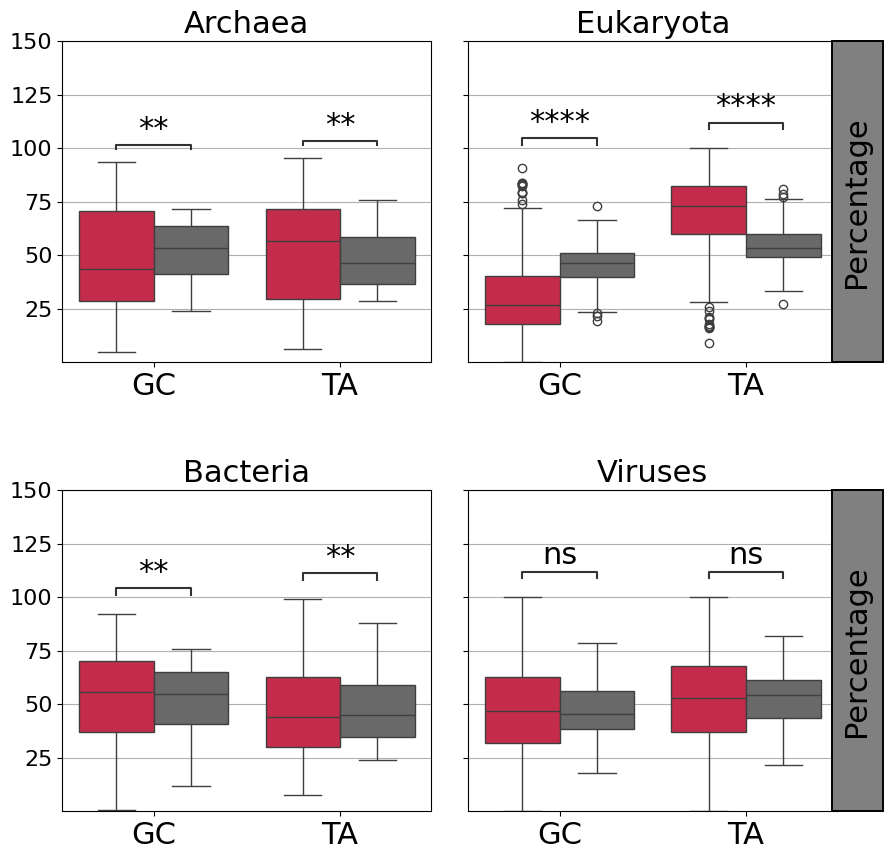

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import polars as pl
import pandas as pd

domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
pdf = IR_df.to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
fig.subplots_adjust(hspace=0.4, wspace=0.1)
axes = axes.flatten()

for i, domain in enumerate(domains):
    df_dom = pdf[pdf["domain"] == domain]
    ax = axes[i]
    sns.boxplot(data=df_dom, 
                width=0.8, 
                x="variable", 
                y="value",
                hue="typ", 
                palette={"IR": "crimson", 
                        "Genome Wide": "dimgray"
                        }, 
                ax=ax)

    pairs = [((var, g1), (var, g2))
             for var in df_dom["variable"].unique()
             for g1, g2 in [df_dom["typ"].unique()[:2]]]

    annotator = Annotator(
        ax,
        pairs,
        data=df_dom,
        x="variable",
        y="value",
        hue="typ"
    )
    annotator.configure(
        test='t-test_ind',
        comparisons_correction='fdr_bh',
        text_format='star',
        loc='inside',
        
        verbose=0,
        fontsize=22
    )
    annotator.apply_and_annotate()
    # ax.axhline(100, color='black', linestyle='--', linewidth=1.5)
    ax.set_axisbelow(True)
    ax.set_title(domain, fontsize=22)
    ax.set_ylim(ymax=150)
    ax.grid(True, axis="y")
    ax.set_xlabel("")
    if i == 0 or i == 2:
        # ax.set_ylabel("Percentage (%)", fontsize=24)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("")
    ax.legend(handles=[], frameon=False)
    ax.tick_params(axis="x", labelsize=22)
    ax.tick_params(axis="y", labelsize=16)
    from matplotlib.patches import Rectangle

    if i == 1 or i == 3:
        ax.add_patch(
            Rectangle(
                (0.985, 0.0),  
                0.14,              
                1.0,                 
                transform=ax.transAxes,
                linewidth=1.4,
                facecolor="gray",
                zorder=10,
                clip_on=False,
                edgecolor="black",
                )
        )
        ax.text(
            1.09, 
            0.5,
            "Percentage",
            transform=ax.transAxes,
            rotation=90,
            va="center",
            ha="right",
            fontsize=22,
            color="black",
            zorder=11
        )


# plt.tight_layout()
plt.show()
fig.savefig(f"{pattern}_figures/biophysical/{pattern}_GC_TA_content_boxplots.pdf", 
            bbox_inches="tight", 
            transparent=True)


In [24]:
alpha = 0.025
quantiles_df = (
                    IR_df
                        .group_by(["domain", "variable", "typ"])
                        .agg(
                            pl.col(f"value").quantile(alpha/2).alias("lower_ci"),
                            pl.col(f"value").quantile(1-alpha/2).alias("upper_ci"),
                            )
            )
quantiles_df

domain,variable,typ,lower_ci,upper_ci
str,str,str,f64,f64
"""Eukaryota""","""GC""","""IR""",3.34105,83.139658
"""Bacteria""","""TA""","""Genome Wide""",27.0,73.0
"""Eukaryota""","""TA""","""IR""",16.860342,96.65895
"""Bacteria""","""GC""","""Genome Wide""",27.0,73.0
"""Bacteria""","""TA""","""IR""",16.948819,85.261383
…,…,…,…,…
"""Viruses""","""GC""","""Genome Wide""",28.0,68.5
"""Viruses""","""TA""","""IR""",10.0,100.0
"""Archaea""","""GC""","""Genome Wide""",29.0,69.0


In [25]:
from bokeh.models import ColumnDataSource, Whisker
from bokeh.plotting import figure, show
from bokeh.transform import jitter
from bokeh.models import ColumnDataSource, Whisker
from bokeh.io import output_notebook, export_svg
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap
from bokeh.models import Span
from bokeh.models.tickers import FixedTicker
from pathlib import Path

In [27]:
arm_GC_enrichment["Eukaryota"]

species_taxid,arm_length,GC_enrichment,domain,q1,q2,q3,iqr,upper,lower
i64,i64,f64,str,f64,f64,f64,f64,f64,f64
27337,10,0.495425,"""Eukaryota""",0.515449,0.667248,0.849946,0.334496,1.35169,0.013705
27337,11,0.5494,"""Eukaryota""",0.445887,0.618573,0.839866,0.393979,1.430835,-0.145081
27337,12,0.599013,"""Eukaryota""",0.381967,0.537037,0.814909,0.432943,1.464323,-0.267447
27337,17,0.780683,"""Eukaryota""",0.211457,0.501195,0.811887,0.60043,1.712532,-0.689188
27337,15,0.466392,"""Eukaryota""",0.263732,0.468218,0.808081,0.544349,1.624604,-0.552792
…,…,…,…,…,…,…,…,…,…
2138604,22,0.151515,"""Eukaryota""",0.107146,0.529216,0.899101,0.791954,2.087033,-1.080785
2138604,24,0.509259,"""Eukaryota""",0.121404,0.478927,0.866929,0.745525,1.985216,-0.996883
2138604,23,0.036232,"""Eukaryota""",0.081878,0.378072,0.839921,0.758043,1.976986,-1.055187


In [87]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

pvals = []
results = []

arm_GC_vs_TA_content = (
                motif_df.filter(pl.col("arm_length") <= 20)
                        .filter(pl.col("#assembly_accession").is_in(selected_accessions))
                        .group_by(["species_taxid", "arm_length"], maintain_order=True)
                        .agg(
                            GC_content=pl.col("GC_content").sum(),
                            total=pl.col("arm_length").count(),
                            # species_taxid=pl.col("species_taxid").first(),
                            domain=pl.col("domain").first(),
                            gc_percent=pl.col("gc_percent").mean(),
                        )
                        .with_columns(
                            total_length=pl.col("arm_length") * pl.col("total")
                        )
                        .with_columns(
                            GC_content=1e2 * pl.col("GC_content") / pl.col("total_length")
                        )
                        .with_columns(
                            TA_content=-100 + pl.col("GC_content")
                        )
)
for domain in domains:
    df_temp = arm_GC_vs_TA_content.filter(pl.col("domain") == domain, pl.col("arm_length") <= 20).to_pandas()
    rho, p = spearmanr(df_temp['GC_content'], df_temp['gc_percent'])
    pvals.append(p)
    results.append((domain, rho, p))

# Adjust for multiple hypothesis (FDR)
rej, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

for i, (domain, rho, p) in enumerate(results):
    print(f"{domain}: Spearman rho = {rho:.3f}, p = {p:.3e}, FDR-adjusted p = {pvals_fdr[i]:.3e}, significant={rej[i]}")

Archaea: Spearman rho = 0.866, p = 0.000e+00, FDR-adjusted p = 0.000e+00, significant=True
Eukaryota: Spearman rho = 0.541, p = 1.039e-215, FDR-adjusted p = 1.039e-215, significant=True
Bacteria: Spearman rho = 0.936, p = 0.000e+00, FDR-adjusted p = 0.000e+00, significant=True
Viruses: Spearman rho = 0.761, p = 0.000e+00, FDR-adjusted p = 0.000e+00, significant=True


In [85]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

pvals = []
results = []

for domain in domains:
    df_temp = arm_GC_enrichment[domain].filter(pl.col("arm_length") <= 20).to_pandas()
    rho, p = spearmanr(df_temp['arm_length'], df_temp['GC_enrichment'])
    pvals.append(p)
    results.append((domain, rho, p))

# Adjust for multiple hypothesis (FDR)
rej, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

for i, (domain, rho, p) in enumerate(results):
    print(f"{domain}: Spearman rho = {rho:.3f}, p = {p:.3e}, FDR-adjusted p = {pvals_fdr[i]:.3e}, significant={rej[i]}")

Archaea: Spearman rho = 0.072, p = 6.507e-05, FDR-adjusted p = 6.507e-05, significant=True
Eukaryota: Spearman rho = -0.193, p = 1.829e-25, FDR-adjusted p = 2.439e-25, significant=True
Bacteria: Spearman rho = -0.291, p = 0.000e+00, FDR-adjusted p = 0.000e+00, significant=True
Viruses: Spearman rho = -0.074, p = 1.216e-47, FDR-adjusted p = 2.432e-47, significant=True


In [126]:
list(reversed(lengths))

[16, 15, 14, 13, 12, 11, 10]

In [129]:
df_temp

,species_taxid,Arm Length (nt),GC_enrichment,domain,q1,q2,q3,iqr,upper,lower
0,2845598,15,0.434783,Viruses,0.752688,0.973236,1.118881,0.366193,1.668171,0.203399
1,1813779,15,0.573477,Viruses,0.752688,0.973236,1.118881,0.366193,1.668171,0.203399
2,2560475,15,1.111111,Viruses,0.752688,0.973236,1.118881,0.366193,1.668171,0.203399
3,2006145,15,0.966184,Viruses,0.752688,0.973236,1.118881,0.366193,1.668171,0.203399
4,2202644,15,1.083475,Viruses,0.752688,0.973236,1.118881,0.366193,1.668171,0.203399
...,...,...,...,...,...,...,...,...,...,...
36117,2897164,10,0.769231,Viruses,0.810811,1.037037,1.212121,0.401310,1.814087,0.208845
36118,2886363,10,1.000000,Viruses,0.810811,1.037037,1.212121,0.401310,1.814087,0.208845
36119,2963165,10,1.318681,Viruses,0.810811,1.037037,1.212121,0.401310,1.814087,0.208845
36120,2963166,10,1.318681,Viruses,0.810811,1.037037,1.212121,0.401310,1.814087,0.208845


In [161]:
df_temp["arm_length"].max()

13

In [166]:
!pip install -q diptest

Archaea Dip Test: DIP=0.0319, p-value=6.831e-04 (arm_length 10)
  -> Significant multimodality detected for arm length 10 in Archaea (p=6.831e-04)
Archaea Dip Test: DIP=0.0184, p-value=2.703e-01 (arm_length 11)
Archaea Dip Test: DIP=0.0194, p-value=2.242e-01 (arm_length 12)
Archaea Dip Test: DIP=0.0168, p-value=5.632e-01 (arm_length 13)
Archaea Dip Test: DIP=0.0166, p-value=7.708e-01 (arm_length 14)
Archaea Dip Test: DIP=0.0198, p-value=7.777e-01 (arm_length 15)
Eukaryota Dip Test: DIP=0.0174, p-value=8.439e-01 (arm_length 10)
Eukaryota Dip Test: DIP=0.0144, p-value=9.814e-01 (arm_length 11)
Eukaryota Dip Test: DIP=0.0146, p-value=9.750e-01 (arm_length 12)
Eukaryota Dip Test: DIP=0.0137, p-value=9.905e-01 (arm_length 13)
Eukaryota Dip Test: DIP=0.0147, p-value=9.787e-01 (arm_length 14)
Eukaryota Dip Test: DIP=0.0199, p-value=6.789e-01 (arm_length 15)
Bacteria Dip Test: DIP=0.0015, p-value=1.000e+00 (arm_length 10)
Bacteria Dip Test: DIP=0.0029, p-value=8.640e-01 (arm_length 11)
Bacteri

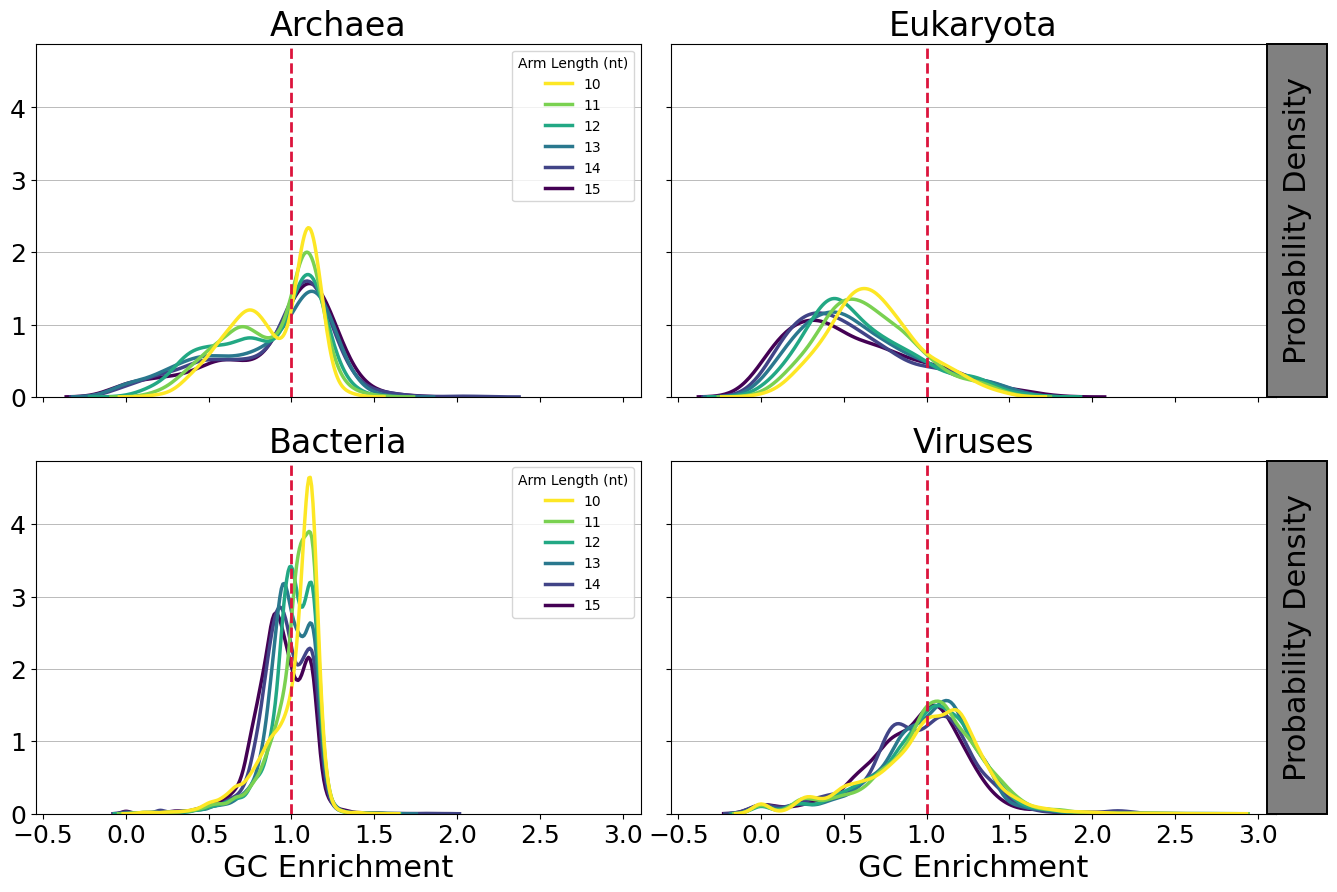

,domain,arm_length,dip,p_value,fdr,significant
0,Archaea,10,0.031932,0.000683,0.001822,**
1,Archaea,11,0.018376,0.270303,0.499021,ns
2,Archaea,12,0.019372,0.224162,0.448325,ns
3,Archaea,13,0.016779,0.563179,0.965451,ns
4,Archaea,14,0.016612,0.770800,1.000000,ns
5,Archaea,15,0.019781,0.777686,1.000000,ns
6,Eukaryota,10,0.017363,0.843909,1.000000,ns
7,Eukaryota,11,0.014351,0.981402,1.000000,ns
8,Eukaryota,12,0.014639,0.975040,1.000000,ns
9,Eukaryota,13,0.013688,0.990484,1.000000,ns


In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from diptest import diptest

fig, axes = plt.subplots(nrows=2, ncols=2, sharey=True, sharex=True, figsize=(16, 10))
fig.subplots_adjust(hspace=0.18, wspace=0.05)
axes = axes.flatten()
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"] 
colors = sns.color_palette("viridis_r", n_colors=7)
palette = {"Left Arm": "purple", "Right Arm": "skyblue"}
lengths = list(range(10, 16))
pvalues = []
for i, domain in enumerate(domains):
    ax = axes[i]
    df_temp = arm_GC_enrichment[domain].filter(pl.col("arm_length") <= max(lengths)).sort(["GC_enrichment", "arm_length"], descending=True)
    for l in lengths:
        vector = df_temp.filter(pl.col("arm_length") == l).select("GC_enrichment").to_series().to_numpy()
        dip, pval = diptest(vector)
        print(f"{domain} Dip Test: DIP={dip:.4f}, p-value={pval:.3e} (arm_length {l})")
        pvalues.append(
            {"domain": domain,
             "arm_length": l,
             "dip": dip,
             "p_value": pval
            })
        if pval < 0.05:
            print(f"  -> Significant multimodality detected for arm length {l} in {domain} (p={pval:.3e})")

    df_temp = df_temp.rename({"arm_length": "Arm Length (nt)"}).to_pandas()
    # df_spacer_temp = spacer_GC_enrichment[domain].filter(pl.col("spacer_length") <= 14).to_pandas()

    ax.set_title(domain, fontsize=24)
    sns.kdeplot(data=df_temp, 
                x="GC_enrichment", 
                hue="Arm Length (nt)", 
                hue_order=[16, 15, 14, 13, 12, 11, 10],
                palette="viridis_r",
                ax=ax,
                linewidth=2.5,
                common_norm=False,
                legend=(i==0 or i==2), 
                fill=False, 
                bw_adjust=1.0)
    ax.axvline(1.0, color='crimson', linestyle='--', linewidth=2, zorder=5
               )
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles=handles, labels=labels, prop={"size": 14})
    # ax.legend(
    #     # handles=[mpatches.Patch(label=f"{length} nt", color=color) for length, color in zip(range(10, 17), sns.color_palette("viridis", n_colors=7))], 
    #         handles=[Line2D([0], [0], color=color, lw=3, label=f"{length} nt") for length, color in zip(lengths, colors)],

    #           prop={"size": 10}, 
    #           fancybox=True, 
    #           frameon=True, 
    #           # title="Arm Length (nt)",
    #           title="",
    #           title_fontsize=14)
    ax.tick_params(axis="both", labelsize=18)
    ax.set_xlabel("GC Enrichment", fontsize=22)
    ax.set_ylabel("", fontsize=20)

    ax.grid(True, axis="y", lw=0.6)
    ax.set_axisbelow(True)
    from matplotlib.patches import Rectangle

    if i == 1 or i == 3:
        ax.add_patch(
            Rectangle(
                (0.985, 0.0),  
                0.1,              
                1.0,                 
                transform=ax.transAxes,
                linewidth=1.4,
                facecolor="gray",
                zorder=10,
                clip_on=False,
                edgecolor="black",
                )
        )
        ax.text(
            1.06, 
            0.5,
            "Probability Density",
            transform=ax.transAxes,
            rotation=90,
            va="center",
            ha="right",
            fontsize=22,
            color="black",
            zorder=11
        )

fig.savefig(target / "IR_motif_arm_GC_enrichment_kde_plots.pdf", transparent=True, bbox_inches="tight")
plt.show()

def map_stars(pvalue: float) -> str:
    if pvalue < 0.0001:
        return "****"
    elif pvalue < 0.001:
        return "***"
    elif pvalue < 0.01:
        return "**"
    elif pvalue < 0.05:
        return "*"
    else:
        return "ns"
pvalues = pd.DataFrame(pvalues)
pvalues["fdr"] = multipletests(pvalues["p_value"], method='fdr_bh')[1] 
pvalues.loc[:, "significant"] = pvalues["fdr"].apply(map_stars)
pvalues

In [151]:
import numpy as np
import polars as pl
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
arm_lengths = range(10, 21)

raw_entries = []       # store rows before FDR
pvals = []             # collect p-values for FDR

for domain in domains:
    df_temp = arm_GC_enrichment[domain]

    for L in arm_lengths:
        vec = df_temp.filter(pl.col("arm_length") == L).get_column("GC_enrichment").to_numpy()
        diffs = vec - 1.0   # >0 enrichment, <0 depletion

        if diffs.size == 0 or np.allclose(diffs, 0):
            raw_entries.append({
                "domain": domain,
                "arm_length": L,
                "n": int(diffs.size),
                "stat": np.nan,
                "p_two_sided": np.nan,
                "effect_r": np.nan,
                "direction": None,
                "median": float(np.nan)
            })
            pvals.append(np.nan)
            continue

        # ---- one two-sided test ----
        stat, p_two = wilcoxon(diffs, zero_method="wilcox",
                               alternative="two-sided", method="approx")

        n = diffs.size

        # Recover |z|
        if np.isfinite(p_two) and p_two > 0:
            z_abs = norm.isf(p_two / 2.0)
        else:
            z_abs = np.nan

        # signed effect direction from median
        med = np.median(diffs)
        sign = np.sign(med)

        # signed effect size r
        effect_r = float(sign * z_abs / np.sqrt(n)) if np.isfinite(z_abs) else np.nan

        raw_entries.append({
            "domain": domain,
            "arm_length": L,
            "n": int(n),
            "stat": float(stat),
            "p_two_sided": float(p_two),
            "effect_r": effect_r,
            "direction": "enrichment" if sign > 0 else ("depletion" if sign < 0 else "neutral"),
            "median": float(med)
        })

        pvals.append(p_two)

# -----------------------------
# FDR CORRECTION (BH)
# -----------------------------
pvals = np.array(pvals, dtype=float)
_, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")

# attach FDR back into table
for row, pf in zip(raw_entries, pvals_fdr):
    row["p_fdr"] = float(pf)
    row["significant_fdr"] = (pf < 0.05)

# final dataframe
results_df = pl.DataFrame(raw_entries).sort(["domain", "arm_length"])
results_df

domain,arm_length,n,stat,p_two_sided,effect_r,direction,median,p_fdr,significant_fdr
str,i64,i64,f64,f64,f64,str,f64,f64,f64
"""Archaea""",10,528,39035.0,1.6404e-18,-0.382084,"""depletion""",-0.061106,3.1381e-18,1.0
"""Archaea""",11,527,42990.0,3.0014e-14,-0.330985,"""depletion""",-0.034825,4.8912e-14,1.0
"""Archaea""",12,506,36699.0,1.1769e-16,-0.368332,"""depletion""",-0.058068,2.0714e-16,1.0
"""Archaea""",13,447,32659.0,1.9015e-10,-0.301248,"""depletion""",-0.039997,2.6989e-10,1.0
"""Archaea""",14,355,24374.0,0.000257,0.194018,"""enrichment""",0.012736,0.000305,1.0
…,…,…,…,…,…,…,…,…,…
"""Viruses""",16,959,152018.0,8.2753e-19,-0.285983,"""depletion""",-0.067164,1.6551e-18,1.0
"""Viruses""",17,519,43820.0,4.5432e-12,-0.303718,"""depletion""",-0.071207,6.6633e-12,1.0
"""Viruses""",18,356,18078.0,1.8132e-12,-0.373551,"""depletion""",-0.097426,2.8493e-12,1.0


In [152]:
results_df.filter(pl.col("domain") == "Viruses").to_pandas()

,domain,arm_length,n,stat,p_two_sided,effect_r,direction,median,p_fdr,significant_fdr
0,Viruses,10,14277,46648773.5,8.764090e-09,0.048148,enrichment,0.037037,1.205062e-08,1.0
1,Viruses,11,9043,18242860.5,1.558353e-17,0.089624,enrichment,0.043219,2.856980e-17,1.0
2,Viruses,12,5500,6975265.5,3.777907e-06,0.062340,enrichment,0.041667,4.749369e-06,1.0
3,Viruses,13,3600,3095217.5,1.949500e-02,0.038932,enrichment,0.037165,2.257316e-02,1.0
4,Viruses,14,2216,1058629.5,4.642484e-08,-0.116082,depletion,-0.029554,6.007921e-08,1.0
5,Viruses,15,1486,434133.0,3.390564e-12,-0.180564,depletion,-0.026764,5.144304e-12,1.0
6,Viruses,16,959,152018.0,8.275348e-19,-0.285983,depletion,-0.067164,1.655070e-18,1.0
7,Viruses,17,519,43820.0,4.543150e-12,-0.303718,depletion,-0.071207,6.663287e-12,1.0
8,Viruses,18,356,18078.0,1.813163e-12,-0.373551,depletion,-0.097426,2.849255e-12,1.0
9,Viruses,19,230,7709.0,3.442890e-08,-0.363799,depletion,-0.190283,4.590520e-08,1.0


In [153]:
results_df.filter(pl.col("domain") == "Eukaryota").to_pandas()

,domain,arm_length,n,stat,p_two_sided,effect_r,direction,median,p_fdr,significant_fdr
0,Eukaryota,10,289,2562.0,2.917164e-38,-0.760787,depletion,-0.332752,1.069627e-37,1.0
1,Eukaryota,11,289,2423.0,8.139189e-39,-0.766537,depletion,-0.381427,3.255676e-38,1.0
2,Eukaryota,12,288,2661.0,1.134752e-37,-0.755929,depletion,-0.463297,3.840699e-37,1.0
3,Eukaryota,13,285,2740.0,9.194143e-37,-0.750234,depletion,-0.470899,2.696949e-36,1.0
4,Eukaryota,14,281,2365.0,1.737393e-37,-0.763315,depletion,-0.496726,5.460378e-37,1.0
5,Eukaryota,15,273,2627.0,7.979440e-35,-0.745049,depletion,-0.531782,2.065267e-34,1.0
6,Eukaryota,16,263,1788.0,1.863507e-36,-0.777557,depletion,-0.574830,5.124644e-36,1.0
7,Eukaryota,17,251,1759.0,2.875143e-34,-0.770458,depletion,-0.498805,7.028127e-34,1.0
8,Eukaryota,18,233,1531.0,7.176163e-32,-0.769679,depletion,-0.619482,1.661848e-31,1.0
9,Eukaryota,19,209,2034.0,1.750417e-24,-0.706385,depletion,-0.607383,3.667541e-24,1.0


In [88]:
results_df.filter(pl.col("domain") == "Archaea").to_pandas()

,domain,arm_length,n,stat,p_two_sided,effect_r,direction,median,p_fdr,significant_fdr
0,Archaea,10,528,39035.0,1.640391e-18,-0.382084,depletion,-0.061106,3.138140e-18,1.0
1,Archaea,11,527,42990.0,3.001415e-14,-0.330985,depletion,-0.034825,4.891194e-14,1.0
2,Archaea,12,506,36699.0,1.176915e-16,-0.368332,depletion,-0.058068,2.071370e-16,1.0
3,Archaea,13,447,32659.0,1.901471e-10,-0.301248,depletion,-0.039997,2.698862e-10,1.0
4,Archaea,14,355,24374.0,2.565947e-04,0.194018,enrichment,0.012736,3.051397e-04,1.0
5,Archaea,15,245,12788.0,4.008645e-02,0.131152,enrichment,0.032548,4.522574e-02,1.0
6,Archaea,16,178,7140.0,2.304849e-01,0.089877,enrichment,0.019735,2.535334e-01,0.0
7,Archaea,17,108,2694.0,4.453213e-01,-0.073443,depletion,-0.028347,4.665270e-01,0.0
8,Archaea,18,69,1149.0,7.265043e-01,0.042108,enrichment,0.060221,7.265043e-01,0.0
9,Archaea,19,37,275.0,2.484319e-01,-0.189744,depletion,-0.005387,2.666098e-01,0.0


In [71]:
results_df.filter(pl.col("domain") == "Bacteria").to_pandas()

,domain,arm_length,n,stat,p_two_sided,effect_r,direction,median,p_fdr,significant_fdr
0,Bacteria,10,11118,25213051.5,7.397893e-63,0.158704,enrichment,0.064604,3.616748e-62,1.0
1,Bacteria,11,11105,22204477.5,9.875551e-144,0.242237,enrichment,0.048710,6.207489e-143,1.0
2,Bacteria,12,11097,26014549.0,4.278587e-44,0.132217,enrichment,0.017684,1.882578e-43,1.0
3,Bacteria,13,11051,29200438.5,9.145698e-05,-0.037215,depletion,-0.008547,1.117807e-04,1.0
4,Bacteria,14,11004,21993457.0,9.445502e-136,-0.236396,depletion,-0.038721,5.195026e-135,1.0
5,Bacteria,15,10931,17439788.5,2.067268e-308,-0.359056,depletion,-0.061489,1.515997e-307,1.0
6,Bacteria,16,10727,13694291.0,0.000000e+00,NaN,depletion,-0.080882,0.000000e+00,1.0
7,Bacteria,17,10332,12020995.0,0.000000e+00,NaN,depletion,-0.089636,0.000000e+00,1.0
8,Bacteria,18,9821,10349759.0,0.000000e+00,NaN,depletion,-0.097816,0.000000e+00,1.0
9,Bacteria,19,8990,8470183.0,0.000000e+00,NaN,depletion,-0.104143,0.000000e+00,1.0


In [78]:

domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812',
                'Viruses': '#229ad6',
}
target = Path(f"{pattern}_figures/biophysical")

figures = []
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
for i, domain in enumerate(domains):
    arm_lengths = (9.5, 20.5)
    source = ColumnDataSource(arm_GC_enrichment[domain].filter(pl.col("arm_length") <= 20).to_pandas())
    p  = figure(x_range=arm_lengths, 
           tools="", 
           toolbar_location=None,
           title=domain,
           height=600,
           output_backend="svg",
           width=800,
    )
    span = Span(location=1.0, 
                dimension='width', 
                line_color='crimson', 
                line_dash='dashed', 
                line_width=4)
    p.add_layout(span)
    p.x_range.start = 9.5
    p.x_range.end = 20.5
    p.title.align = "center"
    p.title.text_font_size = "44pt"
    p.title.text_font_style = "normal"
    whisker = Whisker(base="arm_length", 
                      upper="upper", 
                      lower="lower", 
                      source=source)
    whisker.upper_head.size = whisker.lower_head.size = 20
    p.add_layout(whisker)
    p.vbar("arm_length", 0.7, "q2", "q3", 
           source=source, 
           color=domain_colors[domain], 
           line_color="black")
    p.vbar("arm_length", 0.7, "q1", "q2", 
           source=source, 
           color=domain_colors[domain], 
           line_color="black")
    outliers = (
                arm_GC_enrichment[domain]
                    .filter(
                            (pl.col("GC_enrichment") < pl.col("lower")) 
                            | (pl.col("GC_enrichment") > pl.col("upper"))
                            )
                )
    p.scatter("arm_length", 
              "GC_enrichment", 
              source=outliers, 
              size=6, 
              color="black", 
              alpha=0.3)
    
    if i == 0 or i == 2:
       p.yaxis.axis_label = "GC Enrichment"
    else:
       p.yaxis.axis_label = ' '
    if i == 3 or i == 2:
       p.xaxis.axis_label = "Arm Length (nt)"
    else:
       p.xaxis.axis_label = ' '
    p.xaxis.ticker = FixedTicker(ticks=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
    p.xgrid.grid_line_color = None
    p.axis.major_label_text_font_size="36pt"
    p.axis.axis_label_text_font_size="42pt"
    p.xaxis.major_label_text_font_size = "34pt"
    p.axis.axis_label_text_font_style="normal"
    # export_svg(p, filename=str(target / f"{pattern}_arm_GC_enrichment_boxplots_{domain}.svg"))
    # show(p)
    figures.append(p)
    
from bokeh.layouts import gridplot 
from pathlib import Path
grid = gridplot([[figures[0], figures[1]], 
                 [figures[2], figures[3]]], 
                 toolbar_location=None)
target = Path(f"{pattern}_figures/biophysical")
target.mkdir(exist_ok=True, parents=False)
from bokeh.io import export_svgs, export_svg
export_svg(grid, filename=str(target / f"{pattern}_arm_GC_enrichment_boxplots.svg"))
show(grid)

In [79]:
from bokeh.layouts import gridplot 
from bokeh.io import export_svgs

figures = []
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
for i, domain in enumerate(domains):
    spacer_lengths = (-0.5, 8.5)
    source = ColumnDataSource(spacer_GC_enrichment[domain].to_pandas())
    p  = figure(x_range=spacer_lengths, 
           tools="", 
           toolbar_location=None,
           title=domain,
           height=600,
           output_backend="svg",
           width=800,
           # y_axis_label="GC Enrichment",
           # x_axis_label="Spacer Length (nt)",
    )
    span = Span(location=1.0, 
                dimension='width', 
                line_color='crimson', 
                line_dash='dashed', 
                line_width=4)
    p.add_layout(span)
    p.x_range.start = -0.5
    p.x_range.end = 8.5
    p.title.align = "center"
    p.title.text_font_size = "44pt"
    p.title.text_font_style = "normal"
    whisker = Whisker(base="spacer_length", upper="upper", lower="lower", source=source)
    whisker.upper_head.size = whisker.lower_head.size = 20
    p.add_layout(whisker)
    p.vbar("spacer_length", 0.7, "q2", "q3", 
           source=source, 
           color=domain_colors[domain], 
           line_color="black")
    p.vbar("spacer_length", 0.7, "q1", "q2", 
           source=source, 
           color=domain_colors[domain], 
           line_color="black")
    outliers = (
                spacer_GC_enrichment[domain]
                    .filter(
                            (pl.col("GC_enrichment") < pl.col("lower")) 
                            | (pl.col("GC_enrichment") > pl.col("upper"))
                            )
                )
    p.scatter("spacer_length", 
              "GC_enrichment", 
              source=outliers, 
              size=6, 
              color="black", 
              alpha=0.3)
    if i == 0 or i == 2:
       p.yaxis.axis_label = "GC Enrichment"
    else:
       p.yaxis.axis_label = ' '
    if i == 3 or i == 2:
       p.xaxis.axis_label = "Spacer Length (nt)"
    else:
       p.xaxis.axis_label = ' '
    p.xaxis.ticker = FixedTicker(ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8])
    p.xgrid.grid_line_color = None
    p.axis.major_label_text_font_size="36pt"
    p.axis.axis_label_text_font_size="42pt"
    p.xaxis.major_label_text_font_size = "34pt"
    p.axis.axis_label_text_font_style="normal"
    figures.append(p)
    

grid = gridplot([[figures[0], figures[1]], [figures[2], figures[3]]], toolbar_location=None)
target = Path(f"{pattern}_figures/biophysical")
target.mkdir(exist_ok=True, parents=False)
export_svg(grid, filename=str(target / f"{pattern}_spacer_GC_enrichment_boxplots.svg"))
show(grid)

In [47]:
GC_enrichment_df = ( 
                motif_df.group_by(["#assembly_accession", "spacer_length", "arm_length"], maintain_order=True)
                        .agg(
                            species_taxid=pl.col("species_taxid").first(),
                            domain=pl.col("domain").first(),
                            gc_percent=pl.col("gc_percent").first(),
                            GC_content=pl.col("GC_content").sum(),
                            base_pairs=pl.col("arm_length").sum(),
                        )
                        .with_columns(
                            GC_content=1e2 * pl.col("GC_content") / pl.col("base_pairs")
                        )
                        .with_columns(
                            GC_enrichment=pl.col("GC_content") / pl.col("gc_percent")
                        )
                        .group_by(["species_taxid", "spacer_length", "arm_length"], maintain_order=True)
                        .agg(
                            GC_enrichment=pl.col("GC_enrichment").mean(),
                            GC_content=pl.col("GC_content").mean(),
                            domain=pl.col("domain").first(),    
                        )
                        .group_by(["domain", "spacer_length", "arm_length"], maintain_order=True)
                        .agg(
                            GC_enrichment=pl.col("GC_enrichment").median(),
                            GC_content=pl.col("GC_content").median(),
                        )
    )

GC_enrichment_domain = dict()
GC_content_domain = dict()
THRESHOLD = 20
for domain in domains:
    # GC Enrichment
    GC_enrichment_domain[domain] = ( 
                                GC_enrichment_df.filter(pl.col("domain") == domain,
                                                            pl.col("arm_length") <= THRESHOLD)
                                                .sort(by=["arm_length", "spacer_length"])
                                                .pivot(index="arm_length", on="spacer_length", values="GC_enrichment")
    )

    # GC Content
    GC_content_domain[domain] = ( 
                                GC_enrichment_df.filter(pl.col("domain") == domain,
                                                            pl.col("arm_length") <= THRESHOLD)
                                                .sort(by=["arm_length", "spacer_length"])
                                                .pivot(index="arm_length", on="spacer_length", values="GC_content")
    )

GC_enrichment_domain[domain]

arm_length,0,1,2,3,4,5,6,7,8
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
10,0.952381,0.898876,0.954451,1.020408,1.126761,1.126761,1.126761,1.061276,1.012658
11,1.020496,0.999001,0.982801,1.017165,1.057082,0.996264,1.048951,1.069519,1.024328
12,0.992063,0.968992,1.028807,1.041667,1.051051,1.075269,1.041667,1.017812,1.041667
13,0.97371,0.949668,0.839161,1.040283,1.045556,1.148106,1.061008,1.015965,0.961538
14,0.865801,1.020408,0.816327,0.978474,1.020408,0.959488,1.038961,0.909091,0.992063
…,…,…,…,…,…,…,…,…,…
16,0.868056,0.75188,0.867102,0.735294,0.992063,0.95696,0.97419,0.859117,0.827206
17,0.922722,0.682504,0.664573,0.696715,0.944972,1.01899,0.89147,0.904977,0.897308
18,0.637973,0.602453,0.496032,0.848176,0.826446,0.793651,1.035782,0.932249,1.065449


In [73]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, ColorBar, LinearColorMapper
from bokeh.transform import transform
from bokeh.palettes import RdYlBu11
import numpy as np

figures = [] 
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
for k, domain in enumerate(domains):
    df = GC_enrichment_domain[domain].to_pandas()
    x_coords = []
    y_coords = []
    values = []
    
    spacer_lengths = [col for col in df.columns if col != 'arm_length']
    arm_lengths = df['arm_length'].tolist()
    
    for i, arm_length in enumerate(arm_lengths):
        for j, spacer_length in enumerate(spacer_lengths):
            x_coords.append(str(spacer_length))
            y_coords.append(str(arm_length))
            values.append(df.iloc[i][spacer_length])
    
    # Create ColumnDataSource
    source = ColumnDataSource(data=dict(
        x=x_coords,
        y=y_coords,
        values=values
    ))
    
    max_val = max(values)
    min_val = min(values)
    max_deviation = max(abs(max_val - 1), abs(min_val - 1))
    
    custom_palette = [
        '#053061', 
        '#2166ac', 
        '#4393c3', 
        '#92c5de', 
        '#d1e5f0', 
        '#f7f7f7', 
        '#fddbc7', 
        '#f4a582', 
        '#d6604d', 
        '#b2182b', 
        '#67001f'  
    ]
    
    color_mapper = LinearColorMapper(palette=custom_palette,
                                   low=1 - max_deviation, 
                                   high=1 + max_deviation)
    p = figure(title=domain,
               output_backend="svg",
               toolbar_location=None,
               x_range=[str(sl) for sl in spacer_lengths],
               y_range=[str(al) for al in arm_lengths],
               width=600,
               height=600)
    
    p.rect(x='x', y='y', width=1, height=1, 
           source=source,
           fill_color=transform('values', color_mapper),
           line_color=None)
    color_bar = ColorBar(color_mapper=color_mapper, 
                        width=20,  # Increased width
                        location=(0,0),
                        title="GC Enrichment",
                        title_text_align="center",
                        title_text_font_size="28pt",
                        major_label_text_font_size="24pt")  # Larger tick labels
    p.add_layout(color_bar, 'right')
    
    # Styling

    if k == 0 or k == 2:
       p.yaxis.axis_label = f"Arm Length (nt)"
    else:
       p.yaxis.axis_label = " "

    if k == 2 or k == 3:
        p.xaxis.axis_label = f"Spacer Length (nt)"
    else:
        p.xaxis.axis_label = " "

    p.title.align = "center"
    p.title.text_font_style = "normal"
    p.title.text_font_size = "38pt"
    p.axis.axis_label_text_font_style = "normal"
    p.axis.axis_label_text_font_size = "36pt"
    p.axis.major_label_text_font_size = "30pt"
    # p.xaxis.axis_label = "Spacer Length"
    # p.yaxis.axis_label = "Arm Length"
    from bokeh.io import export_svg
    target = Path(f"{pattern}_figures/biophysical")
    target.mkdir(exist_ok=True, parents=False)
    # export_svg(p, filename=str(target / f"{pattern}_{domain}_GC_enrichment_heatmaps.svg"))
    figures.append(p)

from bokeh.layouts import gridplot
grid = gridplot([[figures[0], figures[1]], 
                 [figures[2], figures[3]]], 
                toolbar_location=None)
export_svg(grid, filename=str(target / f"{pattern}_{domain}_GC_enrichment_heatmaps.svg"))
show(grid)

In [41]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, ColorBar, LinearColorMapper
from bokeh.transform import transform
from bokeh.palettes import RdYlBu11
import numpy as np

figures = [] 
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
for k, domain in enumerate(domains):
    df = GC_content_domain[domain].to_pandas()
    x_coords = []
    y_coords = []
    values = []
    
    spacer_lengths = [col for col in df.columns if col != 'arm_length']
    arm_lengths = df['arm_length'].tolist()
    
    for i, arm_length in enumerate(arm_lengths):
        for j, spacer_length in enumerate(spacer_lengths):
            x_coords.append(str(spacer_length))
            y_coords.append(str(arm_length))
            values.append(df.iloc[i][spacer_length])
    
    source = ColumnDataSource(data=dict(
        x=x_coords,
        y=y_coords,
        values=values
    ))
    
    max_val = max(values)
    min_val = min(values)
    color_mapper = LinearColorMapper(palette=RdYlBu11,
                                   low=0,
                                   high=100)
    
    p = figure(title=domain,
               toolbar_location=None,
               output_backend="svg",
               x_range=[str(sl) for sl in spacer_lengths],
               y_range=[str(al) for al in arm_lengths],
               width=600,
               height=600)
    
    p.rect(x='x', y='y', width=1, height=1, 
           source=source,
           fill_color=transform('values', color_mapper),
           line_color=None)
    
    color_bar = ColorBar(color_mapper=color_mapper, 
                        width=20,  # Increased width
                        location=(0,0),
                        title="GC Content (%)",
                        title_text_align="center",
                        title_text_font_size="20pt",
                        major_label_text_font_size="14pt")  
    if k == 0 or k == 2:
       p.yaxis.axis_label = f"Arm Length (nt)"
    else:
       p.yaxis.axis_label = " "
    if k == 2 or k == 3:
        p.xaxis.axis_label = f"Spacer Length (nt)"
    else:
        p.xaxis.axis_label = " "

    p.add_layout(color_bar, 'right')
    p.title.align = "center"
    p.title.text_font_style = "normal"
    p.title.text_font_size = "30pt"
    p.axis.axis_label_text_font_style = "normal"
    p.axis.axis_label_text_font_size = "26pt"
    p.axis.major_label_text_font_size = "20pt"
    # p.xaxis.axis_label = "Spacer Length"
    # p.yaxis.axis_label = "Arm Length"
    figures.append(p)
    from bokeh.io import export_svg
    target = Path(f"{pattern}_figures/biophysical")
    target.mkdir(exist_ok=True, parents=False)
    # export_svg(p, filename=str(target / f"{pattern}_{domain}_GC_content_heatmaps.svg"))

from bokeh.layouts import gridplot
grid = gridplot([[figures[0], figures[1]], [figures[2], figures[3]]], 
                toolbar_location=None)
target = Path(f"{pattern}_figures/biophysical")
target.mkdir(exist_ok=True, parents=False)
from bokeh.io import export_svgs
export_svg(grid, filename=str(target / f"{pattern}_GC_content_heatmaps.svg"))
show(grid)

## Dinucleotide Composition of Arm: Streamplot

In [59]:
from Bio.Seq import Seq 

def canonical_dinucleotides():
    """Return a list of canonical dinucleotides."""
    bases = "agct"
    dinucleotides = dict()
    for b1 in bases:
        for b2 in bases:
            dinuc = b1 + b2
            rev_comp = str(Seq(dinuc).reverse_complement())
            mini = min(dinuc, rev_comp)
            dinucleotides[dinuc] = mini
            dinucleotides[rev_comp] = mini
    return dinucleotides

canonical_dinu = canonical_dinucleotides() 
# 
for key, val in canonical_dinu.items():
    print(key, val) 

def count_dinucleotides(seq: str) -> dict:
    """Count dinucleotides in a given sequence."""
    global canonical_dinu
    from collections import defaultdict
    dinuc_counts = defaultdict(int)
    for i in range(len(seq) - 1):
        dinuc = seq[i:i+2]
        dinuc_counts[canonical_dinu[dinuc]] += 1
    return dict(dinuc_counts)

aa aa
tt aa
ag ag
ct ag
ac ac
gt ac
at at
ga ga
tc ga
gg cc
cc cc
gc gc
ca ca
tg ca
cg cg
ta ta


In [60]:
from collections import defaultdict 
from tqdm import tqdm 
canonical = list(canonical_dinu.values())
total_canonical = len(canonical) 

print(f"Total canonical dinucleotides: {total_canonical}")
sequences = list(set(motif_df["sequence_of_arm"]))
dinucleotide_counts = defaultdict(list)
for seq in tqdm(sequences):
    observed_dinu = count_dinucleotides(seq)
    dinucleotide_counts["sequence"].append(seq)
    assert len(observed_dinu) <= total_canonical
    for di in canonical_dinu:
        dinucleotide_counts[di].append(observed_dinu.get(di, 0))
dinucleotide_counts = pl.from_pandas(pd.DataFrame(dinucleotide_counts))
dinucleotide_counts

Total canonical dinucleotides: 16


100%|██████████| 3755582/3755582 [00:11<00:00, 316353.55it/s]


sequence,aa,tt,ag,ct,ac,gt,at,ga,tc,gg,cc,gc,ca,tg,cg,ta
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""cttgagcaac""",2,0,2,0,1,0,0,1,0,0,0,1,2,0,0,0
"""aaaaggggtc""",3,0,1,0,1,0,0,1,0,0,3,0,0,0,0,0
"""acgccgaggggcccgccaccgc""",0,0,1,0,2,0,0,1,0,0,8,4,1,0,4,0
"""agcctaaatca""",2,0,2,0,0,0,1,1,0,0,1,1,1,0,0,1
"""tgcggcactaa""",1,0,1,0,1,0,0,0,0,0,1,2,2,0,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""acatgttaacatgt""",2,0,0,0,4,0,2,0,0,0,0,0,4,0,0,1
"""gagaaaatacgt""",3,0,1,0,2,0,1,2,0,0,0,0,0,0,1,1
"""acaggctgcgg""",0,0,2,0,1,0,0,0,0,0,2,2,2,0,1,0


In [61]:
canonical = list(set(canonical_dinu.values()))
canonical

['ac', 'gc', 'at', 'aa', 'cg', 'ta', 'ga', 'ag', 'cc', 'ca']

In [62]:

sequence_df = (
       motif_df.join(
              dinucleotide_counts,
                     left_on="sequence_of_arm",
                     right_on="sequence",
                     how="left"
              )
)
sequence_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,species_taxid,organism_name,group,genome_size,gc_percent,domain,phylum,family,kingdom,STR_coverage_sequence,STR_coverage_arm,GC_content,GC_content_perc,aa,tt,ag,ct,ac,gt,at,ga,tc,gg,cc,gc,ca,tg,cg,ta
str,i64,i64,str,i64,str,i64,str,i64,str,i64,str,str,i64,f64,str,str,str,str,i64,i64,u32,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""NC_003551.1""",53509,53539,"""gatgacgtcga""",11,"""gaaggtca""",8,"""gatgacgtcgagaaggtcatcgacgtcatc""",30,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,6,54.545455,0,0,0,0,2,0,1,4,0,0,0,0,1,0,2,0
"""NC_003551.1""",55509,55537,"""tcgtcgggacgac""",13,"""ac""",2,"""tcgtcgggacgacacgtcgtcccgacga""",28,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,9,69.230769,0,0,0,0,3,0,0,4,0,0,2,0,0,0,3,0
"""NC_003551.1""",66661,66683,"""gagcacgctcc""",11,""".""",0,"""gagcacgctccggagcgtgctc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,8,72.727273,0,0,2,0,1,0,0,2,0,0,1,2,1,0,1,0
"""NC_003551.1""",99585,99607,"""gggggctcga""",10,"""tg""",2,"""gggggctcgatgtcgagccccc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,8,80.0,0,0,1,0,0,0,0,2,0,0,4,1,0,0,1,0
"""NC_003551.1""",168786,168808,"""gcggaacgtc""",10,"""ca""",2,"""gcggaacgtccagacgttccgc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,7,70.0,1,0,0,0,2,0,0,2,0,0,1,1,0,0,2,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""OZ001188.1""",2687933,2687961,"""tgcggatgtgg""",11,"""tcacgc""",6,"""tgcggatgtggtcacgcccacatccgca""",28,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,7,63.636364,0,0,0,0,1,0,1,1,0,0,2,1,3,0,1,0
"""OZ001188.1""",2715434,2715463,"""ctcaagctgtt""",11,"""gtgtttg""",7,"""ctcaagctgttgtgtttgaacagcttgag""",29,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,5,45.454545,2,0,3,0,1,0,0,1,0,0,0,1,2,0,0,0
"""OZ001188.1""",2716227,2716254,"""ccgccgctgcg""",11,"""ttcgt""",5,"""ccgccgctgcgttcgtcgcagcggcgg""",27,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,10,90.909091,0,0,1,0,0,0,0,0,0,0,2,3,1,0,3,0


In [63]:
sequence_counts_df =  (
       sequence_df 
       .filter(pl.col("arm_length") < 31)
        .group_by(["species_taxid", "arm_length"])
        .agg(
            *[pl.col(c).sum().alias(c) for c in canonical],
            pl.col("domain").first().alias("domain"),
            pl.col("arm_length").sum().alias("total_base_pairs"),
            pl.col("arm_length").count().alias("total_arms")
        )
        .with_columns(
            (pl.col("total_base_pairs") - pl.col("total_arms")).alias("dinu_base_pairs")
        )
        .with_columns(
            *[(1e2 * pl.col(c) / pl.col("dinu_base_pairs")).round(2).alias(f"{c}_norm") for c in canonical]
        )
        .with_columns(
            probability=pl.sum_horizontal(pl.col(f"{c}_norm") for c in canonical)
        )
        .group_by(["domain", "arm_length"])
        .agg(
           [pl.col(f"{c}_norm").mean().round(2) for c in canonical] 
        )
        .with_columns(
            probability=pl.sum_horizontal(pl.col(f"{c}_norm") for c in canonical)
        )
)
sequence_counts_df

domain,arm_length,ac_norm,gc_norm,at_norm,aa_norm,cg_norm,ta_norm,ga_norm,ag_norm,cc_norm,ca_norm,probability
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Bacteria""",23,9.6,7.54,5.89,18.79,7.28,5.32,10.1,9.94,15.61,9.94,100.01
"""Archaea""",24,6.0,7.58,11.73,22.71,10.01,10.8,10.42,6.52,9.16,5.07,100.0
"""Eukaryota""",12,6.91,4.89,17.63,19.64,4.14,18.17,7.0,8.02,6.22,7.39,100.01
"""Archaea""",26,8.5,11.75,4.25,13.25,16.42,3.5,12.08,8.0,16.25,6.0,100.0
"""Bacteria""",12,7.9,9.96,4.63,18.75,8.54,3.53,9.27,10.44,18.53,8.45,100.0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Bacteria""",10,7.83,10.22,5.73,16.38,9.27,4.02,10.17,9.84,17.21,9.33,100.0
"""Viruses""",26,6.14,3.23,18.05,23.6,1.81,16.53,7.38,6.86,8.17,8.24,100.01
"""Eukaryota""",14,6.58,4.64,20.6,17.23,3.71,21.26,6.0,7.25,5.89,6.84,100.0


In [81]:
from bokeh.palettes import brewer
from bokeh.models import Legend

col_name = "arm_length"
figures = []
spacers = list(range(0, 9))
spacers = list(range(10, 31))
for k, domain in enumerate(domains + ["Viruses"]):
    dinu_df = ( 
                sequence_counts_df
                    .filter(pl.col("domain") == domain)
                    .select([f"{c}_norm" for c in canonical] + [col_name])
                    .sort([col_name])
    )
    p = figure(
            # x_range=(0, 9),
            toolbar_location=None,
            title=domain,
        output_backend="svg",
        height=750,
        width=750,
    )
    p.title.align = 'center'
    p.title.text_font_style = 'normal'
    p.title.text_font_size = '46pt'
    p.x_range.start = min(spacers)
    p.x_range.end = max(spacers)
    p.y_range.start = - 0.0
    p.y_range.end = 100.0
    # p.xaxis.axis_label = f'{pattern} Arm Length (nt)'

    if k == 0 or k == 2:
        p.yaxis.axis_label = 'Percentage (%)'
    else:
        p.yaxis.axis_label = ' '
    if k == 2 or k == 3:
        p.xaxis.axis_label = f'Arm Length (nt)'
    else:
        p.xaxis.axis_label = f' '
    p.axis.axis_label_text_font_style = 'normal'
    p.axis.axis_label_text_font_size = '40pt'
    p.axis.major_label_text_font_size = '36pt'
    source = ColumnDataSource(dinu_df.to_pandas())
    p.varea_stack(stackers=[f"{c}_norm" for c in canonical], 
                  color=brewer['Spectral'][len(canonical)], 
                  legend_label=list(map(str.upper, canonical)),
                  x=col_name, 
                  source=source)
    if k!=4:
        legend = p.legend[0]
        p.legend.visible = False  # hide the auto-added one
    else:
        p.legend.orientation = "horizontal"
        p.legend.background_fill_color = "#fafafa"
        auto_legend = p.legend[0]
        items = auto_legend.items
        # hide auto legend
        p.legend.visible = False
        legend = Legend(items=items,
                        orientation="vertical",
                        label_text_font_size="12pt",
                        glyph_height=18,
                        glyph_width=18,
                        spacing=6,
                        padding=6,
                        border_line_color=None,
                        background_fill_color="#fafafa")
        p.add_layout(legend, "right")
    # p.legend.
    figures.append(p)
    from bokeh.io import export_svg
    target = Path(f"{pattern}_figures/biophysical")
    target.mkdir(exist_ok=True, parents=False)
    # if k!=4:
    #    dest = str(target / f"{pattern}_{domain}_streamplot_dinucleotide.svg")
    # else:
    #    dest = str(target / f"{pattern}_legend_streamplot_dinucleotide.svg")
    # export_svg(p, filename=dest)

grid = gridplot([[figures[0], figures[1]], [figures[2], figures[3]]], toolbar_location=None)
from bokeh.io import export_svg
target = Path(f"{pattern}_figures").joinpath("biophysical")
target.mkdir(exist_ok=True)
export_svg(grid, filename=target / f"{pattern}_streamplot_dinucleotide.svg")
show(grid)

## Spacer Length & Arm Length Distribution

### Figure 2

In [33]:
# Spacer Length

## Calculating total counts on the Assembly Accession level
##
counts_total_df = (
                    motif_df
                    .group_by("#assembly_accession")
                    .agg(
                        total_counts=pl.col("sequence_of_arm").count(),
                        domain=pl.col("domain").first(),
                        species_taxid=pl.col("species_taxid").first(),
                    )
)
    
spacer_counts_df = (
                motif_df
                .group_by(["#assembly_accession", "spacer_length"]) 
                .agg(
                    counts=pl.col("sequence_of_arm").count(),
                    domain=pl.col("domain").first(),
                    species_taxid=pl.col("species_taxid").first(),
                )
                .join(
                    counts_total_df.select(["#assembly_accession", "total_counts"]),
                    on="#assembly_accession",
                    how="left"
                )
                .with_columns(
                    perc_counts=1e2 * pl.col("counts") / pl.col("total_counts")
                )
                .group_by(["species_taxid", "spacer_length"], maintain_order=True)
                .agg(
                    avg_perc_counts=pl.col("perc_counts").mean(),
                    domain=pl.col("domain").first(),
                )
)

# Arm Length
arm_counts_df = (
                motif_df
                .filter(pl.col("arm_length") <= 31)
                .group_by(["#assembly_accession", "arm_length"]) 
                .agg(
                    counts=pl.col("sequence_of_arm").count(),
                    domain=pl.col("domain").first(),
                    species_taxid=pl.col("species_taxid").first(),
                )
                .join(
                    counts_total_df.select(["#assembly_accession", "total_counts"]),
                    on="#assembly_accession",
                    how="left"
                )
                .with_columns(
                    perc_counts=1e2 * pl.col("counts") / pl.col("total_counts")
                )
                .group_by(["species_taxid", "arm_length"], maintain_order=True)
                .agg(
                    avg_perc_counts=pl.col("perc_counts").mean(),
                    domain=pl.col("domain").first(),
                )
)
arm_counts_df

species_taxid,arm_length,avg_perc_counts,domain
i64,i64,f64,str
1124835,25,0.168209,"""Bacteria"""
1719,12,11.553567,"""Bacteria"""
562,16,1.441311,"""Bacteria"""
1352,13,10.629527,"""Bacteria"""
2859227,10,23.624161,"""Bacteria"""
…,…,…,…
2750025,12,10.702614,"""Bacteria"""
251538,12,12.0,"""Bacteria"""
270918,12,12.063492,"""Bacteria"""


In [ ]:
# Arm & Spacer Combined
total_spacer_arm_df = (
                        motif_df
                        .group_by(["#assembly_accession"])
                        .agg(
                            total_motifs=pl.col("start").count(),
                        )
)
#################################
spacer_arm_df = ( 
                motif_df
                    .group_by(["#assembly_accession", "spacer_length", "arm_length"], 
                                maintain_order=True)
                    .agg(
                        species_taxid=pl.col("species_taxid").first(),
                        domain=pl.col("domain").first(),
                        motif_counts=pl.col("arm_length").count(),
                    )
                    .join(
                        total_spacer_arm_df,
                        on="#assembly_accession",
                        how="left"
                    )
                    .with_columns(
                        ratio=1e2 * pl.col("motif_counts") / pl.col("total_motifs")
                    )
                    .group_by(["species_taxid", "spacer_length", "arm_length"], maintain_order=True)
                    .agg(
                        avg_ratio=pl.col("ratio").mean(),
                        domain=pl.col("domain").first(),    
                    )
                    .group_by(["domain", "spacer_length", "arm_length"], maintain_order=True)
                    .agg(
                        avg_ratio=pl.col("avg_ratio").median(),
                    )
    )

spacer_arm_domain = dict()
THRESHOLD = 31
for domain in domains:
    spacer_arm_domain[domain] = ( 
                                spacer_arm_df.filter(pl.col("domain") == domain,
                                                            pl.col("arm_length") <= THRESHOLD)
                                                .with_columns(
                                                    avg_ratio_log=pl.col("avg_ratio").map_elements(lambda x: np.log10(x + 1), return_dtype=pl.Float64)
                                                    )
                                                .sort(by=["arm_length", "spacer_length"])
                                                .pivot(index="arm_length", on="spacer_length", values="avg_ratio_log")
                                .fill_null(0.0)
                                .with_columns(
                                    arm_length=pl.col("arm_length").cast(pl.Int64),

                                )
    )

spacer_arm_domain["Eukaryota"]

arm_length,0,1,2,3,4,5,6,7,8
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
10,1.073789,0.895803,0.763616,0.742381,0.750099,0.750504,0.764485,0.732976,0.747169
11,0.790104,0.558565,0.454332,0.424502,0.464595,0.424634,0.417393,0.430545,0.434756
12,0.553952,0.300894,0.259782,0.22608,0.270865,0.227391,0.241904,0.233653,0.235135
13,0.40245,0.175647,0.155567,0.135617,0.156558,0.129523,0.138184,0.131639,0.143654
14,0.294659,0.113033,0.09942,0.084651,0.098567,0.080952,0.093536,0.090809,0.093376
…,…,…,…,…,…,…,…,…,…
27,0.050656,0.002948,0.002892,0.003264,0.004082,0.001554,0.002988,0.002261,0.003747
28,0.044656,0.003022,0.00342,0.002572,0.00398,0.002077,0.00333,0.002308,0.003241
29,0.041082,0.001781,0.002431,0.001792,0.002327,0.001163,0.002359,0.001306,0.002609


In [57]:
# Arm & Spacer Combined
total_spacer_arm_df = (
                        motif_df
                        .group_by(["#assembly_accession"])
                        .agg(
                            total_motifs=pl.col("start").count(),
                            species_taxid=pl.col("species_taxid").first(),
                        )
                        .sort(["species_taxid", "total_motifs"], descending=True)
                        .unique(["species_taxid"], maintain_order=True, keep="first")
)

total_spacer_arm_df

#assembly_accession,total_motifs,species_taxid
str,u32,i64
"""GCA_037114825.1""",5,3128044
"""GCA_037114785.1""",9,3127874
"""GCA_037114535.1""",7,3127744
"""GCA_037114465.1""",3,3127729
"""GCA_037114455.1""",3,3127728
…,…,…
"""GCF_000012885.1""",337,19
"""GCF_000020965.1""",173,14
"""GCF_000218545.1""",466,11


In [58]:
len(total_spacer_arm_df["species_taxid"].unique())

29788

In [60]:
motif_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,species_taxid,organism_name,group,genome_size,gc_percent,domain,phylum,family,kingdom,STR_coverage_sequence,STR_coverage_arm,GC_content,GC_content_perc,AT_cont,joint,kingdom_updated
str,i64,i64,str,i64,str,i64,str,i64,str,i64,str,str,i64,f64,str,str,str,str,i64,i64,u32,f64,u32,str,str
"""NC_003551.1""",53509,53539,"""gatgacgtcga""",11,"""gaaggtca""",8,"""gatgacgtcgagaaggtcatcgacgtcatc""",30,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,6,54.545455,5,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
"""NC_003551.1""",55509,55537,"""tcgtcgggacgac""",13,"""ac""",2,"""tcgtcgggacgacacgtcgtcccgacga""",28,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,9,69.230769,4,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
"""NC_003551.1""",66661,66683,"""gagcacgctcc""",11,""".""",0,"""gagcacgctccggagcgtgctc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,8,72.727273,3,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
"""NC_003551.1""",99585,99607,"""gggggctcga""",10,"""tg""",2,"""gggggctcgatgtcgagccccc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,8,80.0,2,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
"""NC_003551.1""",168786,168808,"""gcggaacgtc""",10,"""ca""",2,"""gcggaacgtccagacgttccgc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,7,70.0,3,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""OZ001188.1""",2687933,2687961,"""tgcggatgtgg""",11,"""tcacgc""",6,"""tgcggatgtggtcacgcccacatccgca""",28,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,7,63.636364,4,"""Pseudomonadati,Bacteria""","""Pseudomonadati"""
"""OZ001188.1""",2715434,2715463,"""ctcaagctgtt""",11,"""gtgtttg""",7,"""ctcaagctgttgtgtttgaacagcttgag""",29,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,5,45.454545,6,"""Pseudomonadati,Bacteria""","""Pseudomonadati"""
"""OZ001188.1""",2716227,2716254,"""ccgccgctgcg""",11,"""ttcgt""",5,"""ccgccgctgcgttcgtcgcagcggcgg""",27,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,10,90.909091,1,"""Pseudomonadati,Bacteria""","""Pseudomonadati"""


In [61]:

# Arm & Spacer Combined
total_spacer_arm_df = (
                        motif_df
                        .group_by(["#assembly_accession"])
                        .agg(
                            total_motifs=pl.col("start").count(),
                            species_taxid=pl.col("species_taxid").first(),
                        )
                        .sort(["species_taxid", "total_motifs"], descending=True)
                        .unique(["species_taxid"], maintain_order=True, keep="first")
                        .select(["#assembly_accession"])
)

selected_accessions = set(total_spacer_arm_df["#assembly_accession"].to_list())

#################################
spacer_arm_df = ( 
                motif_df
                    .filter(pl.col("#assembly_accession").is_in(selected_accessions))
                    .group_by(["domain", "spacer_length", "arm_length"], maintain_order=True)
                    .agg(
                        motif_counts=pl.col("arm_length").count(),
                    )
                    .with_columns(
                            occurrences=pl.col("motif_counts").map_elements(lambda x: np.log10(x + 1), return_dtype=pl.Float64)
                    )
)

spacer_arm_domain = dict()
THRESHOLD = 31
for domain in domains:
    spacer_arm_domain[domain] = ( 
                                spacer_arm_df.filter(pl.col("domain") == domain,
                                                            pl.col("arm_length") <= THRESHOLD)
                                                .sort(by=["arm_length", "spacer_length"])
                                                .pivot(index="arm_length", on="spacer_length", values="occurrences")
                                .fill_null(0.0)
                                .with_columns(
                                    arm_length=pl.col("arm_length").cast(pl.Int64),
                                )
    )

spacer_arm_domain["Eukaryota"]

arm_length,0,1,2,3,4,5,6,7,8
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
10,5.76629,5.577048,5.426846,5.425149,5.476012,5.395085,5.411436,5.42681,5.563645
11,5.57707,5.164867,5.092022,5.028998,5.158899,5.048624,5.073674,5.050929,5.252455
12,5.36486,4.843177,4.851827,4.735423,4.869754,4.835634,4.903052,4.777717,4.907648
13,5.223883,4.578742,4.575915,4.560636,4.736835,4.553361,4.581301,4.589257,4.736197
14,5.122183,4.417854,4.439033,4.317625,4.457473,4.282871,4.472903,4.299093,4.648409
…,…,…,…,…,…,…,…,…,…
27,4.422705,2.70757,2.943495,2.683947,3.020775,2.718502,2.895975,2.725912,3.387034
28,4.402657,2.696356,2.907949,2.705864,3.011147,2.800029,2.928908,2.775246,3.017451
29,4.380175,2.624282,2.817565,2.49276,2.900367,2.647383,2.766413,2.685742,3.30298


In [69]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, ColorBar, LinearColorMapper
from bokeh.transform import transform
from bokeh.palettes import RdYlBu11
from bokeh.layouts import gridplot
from pathlib import Path

figures = [] 
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]

for k, domain in enumerate(domains):
    df = spacer_arm_domain[domain].to_pandas()
    
    # Melt dataframe to long format (arm_length, spacer_length, value)
    df_long = df.melt(id_vars="arm_length", var_name="spacer_length", value_name="values")
    
    # Convert to strings for categorical axes
    df_long['arm_length'] = df_long['arm_length'].astype(str)
    df_long['spacer_length'] = df_long['spacer_length'].astype(str)
    
    source = ColumnDataSource(df_long)
    
    # Use actual min/max for color scaling
    min_val, max_val = df_long['values'].min(), df_long['values'].max()
    color_mapper = LinearColorMapper(palette=RdYlBu11, low=min_val, high=max_val)
    
    p = figure(
        title=domain,
        toolbar_location=None,
        x_range=sorted(df_long['spacer_length'].unique(), key=int),
        y_range=sorted(df_long['arm_length'].unique(), key=int, reverse=True),
        width=600,
        height=600
    )
    
    p.rect(
        x='spacer_length', 
        y='arm_length', 
        width=1, 
        height=1, 
        source=source,
        fill_color=transform('values', color_mapper),
        line_color=None
    )
    
    color_bar = ColorBar(
        color_mapper=color_mapper,
        width=20,
        location=(0,0),
        title="log₁₀(IR occurrences+1)",
        title_text_align="center",
        title_text_font_size="20pt",
        major_label_text_font_size="14pt"
    )
    p.add_layout(color_bar, 'right')
    
    # Style
    p.title.align = "center"
    p.title.text_font_style = "normal"
    p.title.text_font_size = "30pt"
    p.axis.axis_label_text_font_style = "normal"
    p.axis.axis_label_text_font_size = "26pt"
    p.xaxis.major_label_text_font_size = "22pt"
    p.yaxis.major_label_text_font_size = "18pt"
    
    # Conditional axis labels
    p.xaxis.axis_label = "Spacer Length (nt)"
    p.yaxis.axis_label = "Arm Length (nt)" if k == 0 else " "
    
    figures.append(p)

# Arrange grid
grid = gridplot([[figures[0], figures[1]], [figures[2], figures[3]]], toolbar_location=None)

# Export
target = Path(f"{pattern}_figures/biophysical")
target.mkdir(exist_ok=True, parents=True)

for i, fig in enumerate(figures):
    fig.output_backend = "svg"
    fig_name = target / f"{pattern}_{domains[i]}_heatmap.svg"
    from bokeh.io.export import export_svgs
    export_svgs(fig, filename=str(fig_name))

show(grid)


In [71]:
spacer_occurrences = dict()
arm_occurrences = dict()
# 
domains = ["Eukaryota", "Bacteria", "Archaea", "Viruses"]
# 
for domain in domains:
    temp_df = spacer_counts_df.filter(pl.col("domain") == domain)
    qs = (
        temp_df
        .group_by(["spacer_length"])
        .agg([
            pl.col("avg_perc_counts").quantile(0.25).alias("q1"),
            pl.col("avg_perc_counts").quantile(0.5).alias("q2"),
            pl.col("avg_perc_counts").quantile(0.75).alias("q3"),
        ])
    )
    df = (
        temp_df.join(qs, on=["spacer_length"], how="left")
        .with_columns([
            (pl.col("q3") - pl.col("q1")).alias("iqr"),
            (pl.col("q3") + 1.5 * (pl.col("q3") - pl.col("q1"))).alias("upper"),
            (pl.col("q1") - 1.5 * (pl.col("q3") - pl.col("q1"))).alias("lower"),
        ])
    )
    spacer_occurrences[domain] = df

    # Arm
    temp_df = arm_counts_df.filter(pl.col("domain") == domain)
    qs = (
        temp_df
        .group_by(["arm_length"])
        .agg([
            pl.col("avg_perc_counts").quantile(0.25).alias("q1"),
            pl.col("avg_perc_counts").quantile(0.5).alias("q2"),
            pl.col("avg_perc_counts").quantile(0.75).alias("q3"),
        ])
    )
    df = (
        temp_df.join(qs, on=["arm_length"], how="left")
        .with_columns([
            (pl.col("q3") - pl.col("q1")).alias("iqr"),
            (pl.col("q3") + 1.5 * (pl.col("q3") - pl.col("q1"))).alias("upper"),
            (pl.col("q1") - 1.5 * (pl.col("q3") - pl.col("q1"))).alias("lower"),
        ])
    )
    arm_occurrences[domain] = df

spacer_occurrences["Eukaryota"]

species_taxid,spacer_length,avg_perc_counts,domain,q1,q2,q3,iqr,upper,lower
i64,i64,f64,str,f64,f64,f64,f64,f64,f64
2770021,8,6.091371,"""Eukaryota""",6.995531,8.309945,10.089686,3.094155,14.730919,2.354299
41058,3,10.903874,"""Eukaryota""",6.666667,8.208955,10.081112,3.414446,15.202781,1.544998
1491479,1,13.822526,"""Eukaryota""",9.804578,12.187248,14.802065,4.997487,22.298296,2.308348
1159556,5,5.557484,"""Eukaryota""",6.861314,8.306709,9.786184,2.92487,14.17349,2.474008
9598,8,9.389559,"""Eukaryota""",6.995531,8.309945,10.089686,3.094155,14.730919,2.354299
…,…,…,…,…,…,…,…,…,…
5007,0,34.513274,"""Eukaryota""",19.066148,23.936367,32.009926,12.943778,51.425592,-0.349519
55194,2,11.659193,"""Eukaryota""",7.415991,9.040131,10.821345,3.405354,15.929375,2.30796
3031751,6,8.482871,"""Eukaryota""",6.982544,8.252191,10.061897,3.079353,14.680927,2.363514


In [79]:
from pathlib import Path 
from bokeh.models import ColumnDataSource, Whisker
from bokeh.io import output_notebook, export_svg
from bokeh.layouts import gridplot 
from bokeh.plotting import figure, show
from bokeh.models.tickers import FixedTicker

# output_notebook()

domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812',
                'Viruses': '#229ad6',
}
figures = []
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
for k, domain in enumerate(domains):
    spacer_lengths = (-0.5, 8.5)
    source = ColumnDataSource(spacer_occurrences[domain].to_pandas())
    p  = figure(x_range=spacer_lengths, 
           tools="", 
           toolbar_location=None,
           title=domain,
           height=600,
           output_backend="svg",
           width=800,
           # y_axis_label=f"{pattern} Occurrences (%)",
           # x_axis_label="Spacer Length (nt)",
    )
    p.x_range.start = -0.5
    p.x_range.end = 8.5
    p.title.align = "center"
    p.title.text_font_size = "30pt"
    p.title.text_font_style = "normal"
    whisker = Whisker(base="spacer_length", upper="upper", lower="lower", source=source)
    whisker.upper_head.size = whisker.lower_head.size = 20
    p.add_layout(whisker)
    p.vbar("spacer_length", 0.7, "q2", "q3", 
           source=source, 
           color=domain_colors[domain], 
           line_color="black")
    p.vbar("spacer_length", 0.7, "q1", "q2", 
           source=source, 
           color=domain_colors[domain], 
           line_color="black")
    outliers = (
                spacer_occurrences[domain]
                    .filter(
                            (pl.col("avg_perc_counts") < pl.col("lower")) 
                            | (pl.col("avg_perc_counts") > pl.col("upper"))
                            )
                )
    p.scatter("spacer_length", 
              "avg_perc_counts", 
              source=outliers, 
              size=6, 
              color="black", 
              alpha=0.3)
    p.xaxis.ticker = FixedTicker(ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8])
    p.xgrid.grid_line_color = None
    p.axis.major_label_text_font_size="20pt"
    p.axis.axis_label_text_font_size="32pt"
    p.xaxis.major_label_text_font_size = "26pt"
    p.yaxis.major_label_text_font_size = "26pt"

    p.axis.axis_label_text_font_style="normal"
    if k == 2 or k == 3:
        p.xaxis.axis_label = "Spacer Length (nt)"
    else:
        p.xaxis.axis_label = " "
    if k == 0 or k == 2:
        p.yaxis.axis_label = f"{pattern} Occurrences (%)"
    else:
        p.yaxis.axis_label = " "
    figures.append(p)
    
p = gridplot([[figures[0], figures[1]], [figures[2], figures[3]]], toolbar_location=None)
target = Path(f"{pattern}_figures/biophysical")
target.mkdir(exist_ok=True, parents=False)
export_svgs(p, filename=str(target / f"{pattern}_spacer_occurrences_boxplots.svg"))

['IR_figures/biophysical/IR_spacer_occurrences_boxplots.svg',
 'IR_figures/biophysical/IR_spacer_occurrences_boxplots_1.svg',
 'IR_figures/biophysical/IR_spacer_occurrences_boxplots_2.svg',
 'IR_figures/biophysical/IR_spacer_occurrences_boxplots_3.svg']

In [81]:
from bokeh.io import export_svg 
from pathlib import Path 
from bokeh.models import ColumnDataSource, Whisker
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models.tickers import FixedTicker
from bokeh.layouts import gridplot 

domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812',
                'Viruses': '#229ad6',
}
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
figures = []
for k, domain in enumerate(domains):
    arm_lengths = (9.5, 31.5)
    source = ColumnDataSource(arm_occurrences[domain].to_pandas())
    p  = figure(x_range=arm_lengths, 
           tools="", 
           toolbar_location=None,
           title=domain,
           height=600,
           output_backend="svg",
           width=800,
           # y_axis_label=f"{pattern} Occurrences (%)",
           # x_axis_label="Spacer Length (nt)",
    )
    p.x_range.start = 10.5
    p.x_range.end = 31.5
    p.y_range.end = 100
    p.title.align = "center"
    p.title.text_font_size = "30pt"
    p.title.text_font_style = "normal"
    whisker = Whisker(base="arm_length", upper="upper", lower="lower", source=source)
    whisker.upper_head.size = whisker.lower_head.size = 20
    p.add_layout(whisker)
    p.vbar("arm_length", 0.7, "q2", "q3", 
           source=source, 
           color=domain_colors[domain], 
           line_color="black")
    p.vbar("arm_length", 0.7, "q1", "q2", 
           source=source, 
           color=domain_colors[domain], 
           line_color="black")
    outliers = (
                arm_occurrences[domain]
                    .filter(
                            (pl.col("avg_perc_counts") < pl.col("lower")) 
                            | (pl.col("avg_perc_counts") > pl.col("upper"))
                            )
                )
    p.scatter("arm_length", 
              "avg_perc_counts", 
              source=outliers, 
              size=6,
              color="black", 
              alpha=0.3)
    if k == 0 or k == 2:
       p.yaxis.axis_label=f"{pattern} Occurrences (%)"
    else:
       p.yaxis.axis_label = ""
    if k == 2 or k == 3:
       p.xaxis.axis_label = "Arm Length (nt)"
    else:
       p.xaxis.axis_label = ""
    # p.xaxis.ticker = FixedTicker(ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8])
    p.xgrid.grid_line_color = None
    p.axis.major_label_text_font_size="20pt"
    p.axis.axis_label_text_font_size="32pt"
    p.xaxis.major_label_text_font_size = "26pt"
    p.yaxis.major_label_text_font_size = "26pt"
    p.axis.axis_label_text_font_style="normal"
    figures.append(p)
    
grid = gridplot([[figures[0], figures[1]], [figures[2], figures[3]]], toolbar_location=None)
target = Path(f"{pattern}_figures/biophysical")
target.mkdir(exist_ok=True, parents=False)
export_svgs(grid, filename=str(target / f"{pattern}_arm_occurrences_boxplots.svg"))

['IR_figures/biophysical/IR_arm_occurrences_boxplots.svg',
 'IR_figures/biophysical/IR_arm_occurrences_boxplots_1.svg',
 'IR_figures/biophysical/IR_arm_occurrences_boxplots_2.svg',
 'IR_figures/biophysical/IR_arm_occurrences_boxplots_3.svg']

# Arm AT Content

In [18]:
motif_df = motif_df.with_columns(
    AT_cont=pl.col("sequence_of_arm")
    .str.count_matches("[at]", literal=False)
    )
# motif_df["AT_cont"] = motif_df["sequence_of_arm"].str.count("a|t")
motif_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,species_taxid,organism_name,group,genome_size,gc_percent,domain,phylum,family,kingdom,STR_coverage_sequence,STR_coverage_arm,GC_content,GC_content_perc,AT_cont
str,i64,i64,str,i64,str,i64,str,i64,str,i64,str,str,i64,f64,str,str,str,str,i64,i64,u32,f64,u32
"""NC_003551.1""",53509,53539,"""gatgacgtcga""",11,"""gaaggtca""",8,"""gatgacgtcgagaaggtcatcgacgtcatc""",30,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,6,54.545455,5
"""NC_003551.1""",55509,55537,"""tcgtcgggacgac""",13,"""ac""",2,"""tcgtcgggacgacacgtcgtcccgacga""",28,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,9,69.230769,4
"""NC_003551.1""",66661,66683,"""gagcacgctcc""",11,""".""",0,"""gagcacgctccggagcgtgctc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,8,72.727273,3
"""NC_003551.1""",99585,99607,"""gggggctcga""",10,"""tg""",2,"""gggggctcgatgtcgagccccc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,8,80.0,2
"""NC_003551.1""",168786,168808,"""gcggaacgtc""",10,"""ca""",2,"""gcggaacgtccagacgttccgc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,7,70.0,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""OZ001188.1""",2687933,2687961,"""tgcggatgtgg""",11,"""tcacgc""",6,"""tgcggatgtggtcacgcccacatccgca""",28,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,7,63.636364,4
"""OZ001188.1""",2715434,2715463,"""ctcaagctgtt""",11,"""gtgtttg""",7,"""ctcaagctgttgtgtttgaacagcttgag""",29,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,5,45.454545,6
"""OZ001188.1""",2716227,2716254,"""ccgccgctgcg""",11,"""ttcgt""",5,"""ccgccgctgcgttcgtcgcagcggcgg""",27,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,10,90.909091,1


In [19]:
def find_kingdom(x):
    if isinstance(x, float):
        return ''
    kingdom, domain = x.split(",")
    if domain == "Viruses":
        return "Viruses"
    return kingdom

# motif_df.loc[:, "joint"] = motif_df["kingdom"] + "," + motif_df["domain"]
# motif_df["kingdom_updated"] = motif_df["joint"].apply(find_kingdom)

motif_df = motif_df.with_columns(
                joint=pl.concat_str([pl.col("kingdom"), pl.col("domain")], separator=",")
            )\
            .with_columns(
                kingdom_updated=pl.col("joint")
                        .map_elements(find_kingdom, return_dtype=pl.Utf8)
            )
motif_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,species_taxid,organism_name,group,genome_size,gc_percent,domain,phylum,family,kingdom,STR_coverage_sequence,STR_coverage_arm,GC_content,GC_content_perc,AT_cont,joint,kingdom_updated
str,i64,i64,str,i64,str,i64,str,i64,str,i64,str,str,i64,f64,str,str,str,str,i64,i64,u32,f64,u32,str,str
"""NC_003551.1""",53509,53539,"""gatgacgtcga""",11,"""gaaggtca""",8,"""gatgacgtcgagaaggtcatcgacgtcatc""",30,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,6,54.545455,5,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
"""NC_003551.1""",55509,55537,"""tcgtcgggacgac""",13,"""ac""",2,"""tcgtcgggacgacacgtcgtcccgacga""",28,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,9,69.230769,4,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
"""NC_003551.1""",66661,66683,"""gagcacgctcc""",11,""".""",0,"""gagcacgctccggagcgtgctc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,8,72.727273,3,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
"""NC_003551.1""",99585,99607,"""gggggctcga""",10,"""tg""",2,"""gggggctcgatgtcgagccccc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,8,80.0,2,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
"""NC_003551.1""",168786,168808,"""gcggaacgtc""",10,"""ca""",2,"""gcggaacgtccagacgttccgc""",22,"""GCF_000007185.1""",2320,"""Methanopyrus kandleri AV19""","""archaea""",1694969,61.0,"""Archaea""","""Methanobacteriota""","""Methanopyraceae""","""Methanobacteriati""",0,0,7,70.0,3,"""Methanobacteriati,Archaea""","""Methanobacteriati"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""OZ001188.1""",2687933,2687961,"""tgcggatgtgg""",11,"""tcacgc""",6,"""tgcggatgtggtcacgcccacatccgca""",28,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,7,63.636364,4,"""Pseudomonadati,Bacteria""","""Pseudomonadati"""
"""OZ001188.1""",2715434,2715463,"""ctcaagctgtt""",11,"""gtgtttg""",7,"""ctcaagctgttgtgtttgaacagcttgag""",29,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,5,45.454545,6,"""Pseudomonadati,Bacteria""","""Pseudomonadati"""
"""OZ001188.1""",2716227,2716254,"""ccgccgctgcg""",11,"""ttcgt""",5,"""ccgccgctgcgttcgtcgcagcggcgg""",27,"""GCA_963921245.2""",2026786,"""Rhodospirillales bacterium""","""bacteria""",2827753,54.5,"""Bacteria""","""Pseudomonadota""",null,"""Pseudomonadati""",0,0,10,90.909091,1,"""Pseudomonadati,Bacteria""","""Pseudomonadati"""


In [ ]:
motif_df_gc_agg = motif_df.groupby("species_taxid", as_index=False).agg({"AT_cont": "sum",
                                                           "arm_length": "sum",
                                                           "gc_percent": "first",
                                                                           "organism_name": "first",
                                                                           "phylum": "first",
                                                                           "domain": "first",
                                                                           "kingdom": "first",
                                                                           "genome_size": "first",
                                                                           
                                                          })
motif_df_gc_agg.loc[:, "AT_drive"] = 1e2 * motif_df_gc_agg["AT_cont"] / motif_df_gc_agg["arm_length"]
motif_df_gc_agg.sort_values(by=["AT_drive"], ascending=False)


motif_df_gc_sru_agg = motif_df.groupby(["species_taxid", "sru"], as_index=False).agg({"AT_cont": "sum",
                                                           "arm_length": "sum",
                                                           "gc_percent": "first",
                                                                           "organism_name": "first",
                                                                           "phylum": "first",
                                                                           "domain": "first",
                                                                           "kingdom": "first",
                                                                           "genome_size": "first",
                                                                           
                                                          })
motif_df_gc_sru_agg.loc[:, "AT_drive"] = 1e2 * motif_df_gc_sru_agg["AT_cont"] / motif_df_gc_sru_agg["arm_length"]
motif_df_gc_sru_agg.sort_values(by=["AT_drive"], ascending=False)


motif_df_gc_agg

,species_taxid,AT_cont,arm_length,gc_percent,organism_name,phylum,domain,kingdom,genome_size,AT_drive
0,7,204,2255,67.5,Azorhizobium caulinodans ORS 571,Pseudomonadota,Bacteria,Pseudomonadati,5369772,9.046563
1,9,24060,24997,25.5,Buchnera aphidicola str. Bp (Baizongia pistaciae),Pseudomonadota,Bacteria,Pseudomonadati,618379,96.251550
2,11,345,2577,74.0,Cellulomonas gilvus ATCC 13127,Actinomycetota,Bacteria,Bacillati,3526441,13.387660
3,14,249,347,33.5,Dictyoglomus thermophilum H-6-12,Dictyoglomota,Bacteria,Pseudomonadati,1959987,71.757925
4,19,268,671,55.0,Syntrophotalea carbinolica DSM 2380,Thermodesulfobacteriota,Bacteria,Pseudomonadati,3665893,39.940387
...,...,...,...,...,...,...,...,...,...,...
35738,3127763,1,3,53.0,Klebsiella phage 175029,Uroviricota,Viruses,Heunggongvirae,40628,33.333333
35739,3127946,7,10,37.5,Bacillus phage vB_Bsu_hmny1,Uroviricota,Viruses,Heunggongvirae,18740,70.000000
35740,3127947,7,10,37.5,Bacillus phage vB_Bsu_hmny2,Uroviricota,Viruses,Heunggongvirae,18762,70.000000
35741,3127948,6,12,43.5,Vibrio phage Va-ZX-1,Uroviricota,Viruses,Heunggongvirae,43533,50.000000


In [171]:
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
}
domain_colors.update({"Bacteria": "#8eb812"})

grouped_at_content = STR_df.query("kingdom != ''")\
                           .groupby(["species_taxid", "consensus_length"])\
                           .agg({
                                  "AT_cont": "sum",
                                  "sru": "sum",
                                  "domain": "first",
                                  "kingdom": "first",
                                 })\
                .assign(at_proportion=lambda df: 100 * df['AT_cont'].div(df['sru']))\
                .groupby(["kingdom", "consensus_length"])\
                .agg({
                      "at_proportion": "median", 
                      "domain": "first"
                })

grouped_at_content.reset_index(inplace=True)
grouped_at_content

,kingdom,consensus_length,at_proportion,domain
0,Abadenavirae,1,100.000000,Viruses
1,Abadenavirae,2,50.000000,Viruses
2,Abadenavirae,3,91.666667,Viruses
3,Abadenavirae,4,75.000000,Viruses
4,Abadenavirae,5,80.000000,Viruses
...,...,...,...,...
185,Zilligvirae,4,75.000000,Viruses
186,Zilligvirae,5,100.000000,Viruses
187,Zilligvirae,6,95.833333,Viruses
188,Zilligvirae,8,78.125000,Viruses


In [172]:
grouped_at_pivot = grouped_at_content[["consensus_length", "kingdom", "at_proportion"]].pivot(index="kingdom", 
                                                                                              values="at_proportion", 
                                                                                              columns="consensus_length").dropna()
superkingdom_col = grouped_at_pivot.index.map(lambda x: domain_colors[kingdom_to_domain[x]])
grouped_at_pivot

consensus_length,1,2,3,4,5,6,7,8,9
kingdom,,,,,,,,,
Bacillati,48.095238,28.571429,29.078014,33.615057,26.666667,31.250000,28.571429,30.681818,30.603448
Bamfordvirae,100.000000,75.000000,50.000000,75.000000,80.392029,50.000000,85.714286,84.375000,55.555556
Fungi,86.516854,67.186717,53.098512,61.638008,60.047755,48.134885,53.409802,55.698052,49.839615
Fusobacteriati,97.663043,91.100230,75.045301,88.679245,90.999100,79.200820,95.238095,91.666667,84.722222
Heunggongvirae,100.000000,50.000000,33.333333,62.500000,60.000000,42.156863,57.142857,37.500000,44.444444
Metazoa,96.255505,64.350859,67.545645,73.057578,72.402861,65.164036,70.035409,60.291202,57.926548
Methanobacteriati,88.562092,41.666667,31.573486,32.459966,40.000000,33.333333,57.142857,62.500000,31.111111
Orthornavirae,100.000000,50.000000,66.666667,75.000000,80.000000,83.333333,85.714286,93.750000,88.888889
Plantae,93.473503,74.346548,64.635958,79.438453,73.634892,69.573087,66.113264,74.415205,67.961599


In [173]:
# grouped_at_pivot.dropna(axis=0, inplace=True)

In [174]:
for col in grouped_at_pivot:
    grouped_at_pivot[col] = grouped_at_pivot[col].astype(float)

In [175]:
superkingdom_col = grouped_at_pivot.reset_index()["kingdom"].apply(lambda x: domain_colors[kingdom_to_domain[x]])
superkingdom_col

0     #8eb812
1     #229ad6
2     #edc41f
3     #8eb812
4     #229ad6
5     #edc41f
6     #b2b2ff
7     #229ad6
8     #edc41f
9     #b2b2ff
10    #edc41f
11    #8eb812
12    #229ad6
13    #229ad6
14    #b2b2ff
15    #8eb812
Name: kingdom, dtype: object